In [1]:
pip install rioxarray stackstac planetary_computer

Note: you may need to restart the kernel to use updated packages.


# **GEE-PYTHON**

# **V1.0**


=== Inisialisasi Google Earth Engine ===
-> GEE siap dipakai.

=== PENGATURAN WAKTU ANALISIS ===
Ketik bulan & tahun TERBARU untuk dianalisis (Format YYYY-MM, contoh: 2026-07):
-> Periode analisis ditarik 13 bulan ke belakang.
-> Mulai dari Sep25 hingga Sep26.

=== TAHAP 1: Membaca Mask Sawah ===
-> Mask terbaca. Piksel sawah: 999012 (9990.12 Ha)

=== TAHAP 3: Mengunduh Komposit Bulanan Gabungan (GEE, 1 file/bulan) ===
Generating URL ...
Please wait ...
Data downloaded to d:\Projects\Information-System\agriculture-python-model\paddy\data\processed\cache_komposit_bulanan_gee\komposit_Sep25_NDVI.tif
Generating URL ...
Please wait ...
Data downloaded to d:\Projects\Information-System\agriculture-python-model\paddy\data\processed\cache_komposit_bulanan_gee\komposit_Sep25_LSWI.tif
Generating URL ...
Please wait ...
Data downloaded to d:\Projects\Information-System\agriculture-python-model\paddy\data\processed\cache_komposit_bulanan_gee\komposit_Sep25_EVI2.tif
Generating URL ...
Please wait

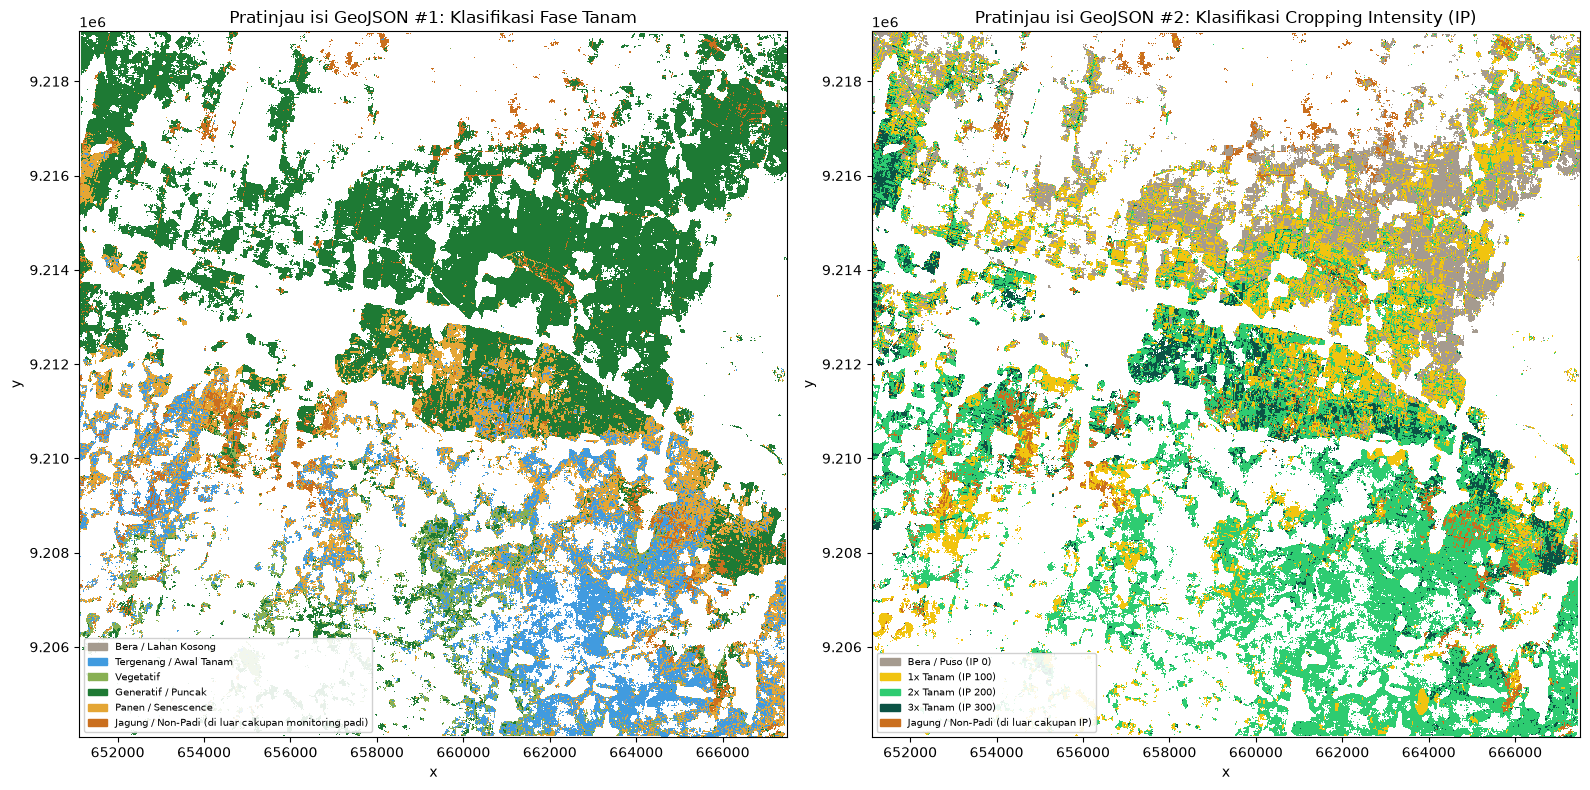


=> 3. Time Series Fenologi


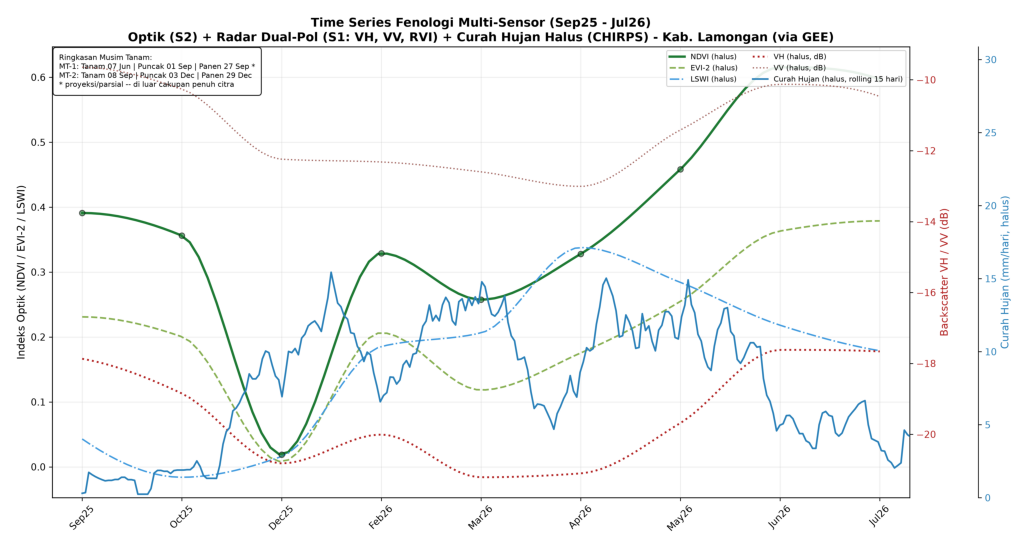


=> 4. Grafik Luas Fase Tanam


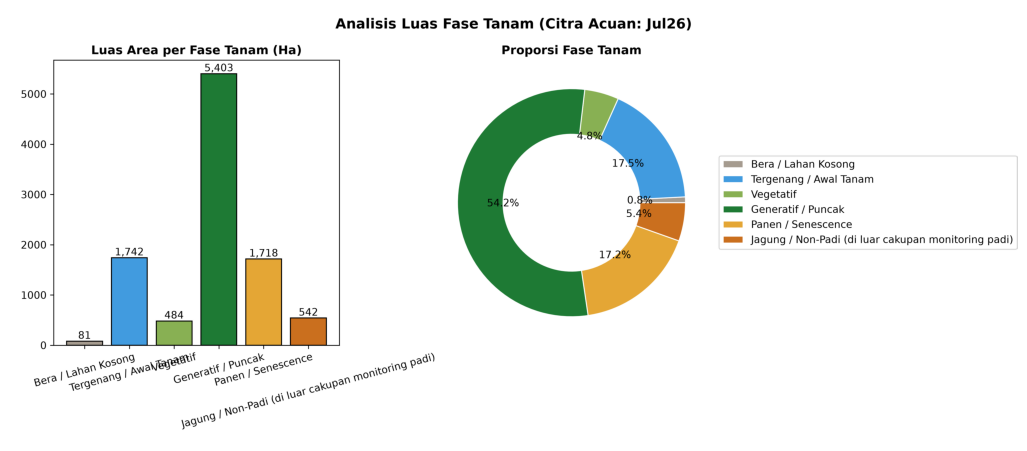


=> 5. Grafik Luas Cropping Intensity


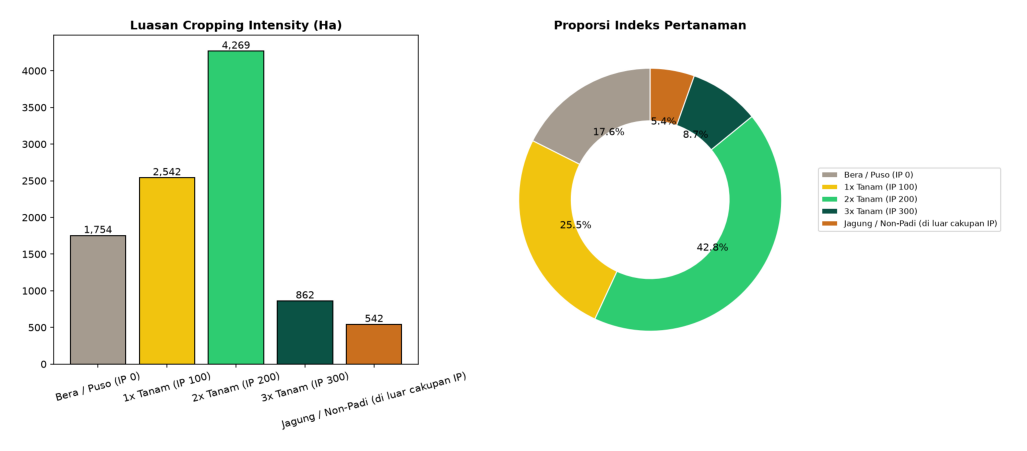

In [2]:
import os
import gc
import warnings
from datetime import datetime

import numpy as np
import pandas as pd
import xarray as xr
import rioxarray  # noqa: F401
import rasterio
from rasterio.features import shapes as rio_shapes
import geopandas as gpd
from shapely.geometry import box, shape as shapely_shape
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.offsetbox import AnchoredText
from scipy.signal import find_peaks
from scipy.interpolate import PchipInterpolator, interp1d

import ee
import geemap

warnings.filterwarnings("ignore")

# ==============================================================================
# 0. KONFIGURASI
# ==============================================================================
EE_PROJECT = "poetic-emblem-487109-t6"  # <-- GANTI dgn Project ID GEE/GCP Anda

EPSG_UTM = 32749
RESOLUSI_M = 10

RAW_DIR = "../../data/raw"
PROCESSED_DIR = "../../data/processed"
FIGURES_DIR = "../../results/figures/module_2"
os.makedirs(PROCESSED_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

MASK_SAWAH_PATH = os.path.join(PROCESSED_DIR, "Klasifikasi_Sawah.tif")
MODULE_DIR = os.path.join(PROCESSED_DIR, "module_2")
os.makedirs(MODULE_DIR, exist_ok=True)
FOLDER_CACHE = os.path.join(MODULE_DIR, "cache_komposit_bulanan_gee")
os.makedirs(FOLDER_CACHE, exist_ok=True)

# Window waktu (13 bulan) - Variabel dinamis akan digenerate saat runtime
JUMLAH_BULAN = 13

CLOUD_MAX_UTAMA = 20
CLOUD_MAX_FALLBACK = 40
CLOUD_MAX_DARURAT = 60
MIN_SCENE_PER_BULAN = 3      # target minimal scene S2 per bulan (bisa diubah ke 4)
ORBIT_PASS_S1 = "DESCENDING"

NODATA = 255
WARNA_JAGUNG = "#CA6F1E"   # cokelat-jingga "tongkol jagung" - sengaja beda dr palet padi

LABEL_FASE = {
    0: "Bera / Lahan Kosong", 1: "Tergenang / Awal Tanam",
    2: "Vegetatif", 3: "Generatif / Puncak", 4: "Panen / Senescence",
    5: "Jagung / Non-Padi (di luar cakupan monitoring padi)",
}
WARNA_FASE = {
    0: "#A59B8F", 1: "#419BDF", 2: "#88B053", 3: "#1E7A34", 4: "#E4A635",
    5: WARNA_JAGUNG,
}
LABEL_IP = {
    0: "Bera / Puso (IP 0)", 1: "1x Tanam (IP 100)",
    2: "2x Tanam (IP 200)", 3: "3x Tanam (IP 300)",
    4: "Jagung / Non-Padi (di luar cakupan IP)",
}
WARNA_IP = {
    0: "#A59B8F", 1: "#F1C40F", 2: "#2ECC71", 3: "#0B5345",
    4: WARNA_JAGUNG,
}

# --- Referensi fenologi padi: Fernandez-Jibaja et al. (2025) ---
FASE_FENOLOGI_DAS = {
    "Seedling": 11, "Tillering": 30, "Maximum Tillering": 48,
    "Inflorescence Emergence": 68, "Flowering": 86, "Ripening": 104,
}
DAS_ANCHOR_PUNCAK_NDVI = FASE_FENOLOGI_DAS["Flowering"]           # 86 HST
DAS_ANCHOR_PANEN = FASE_FENOLOGI_DAS["Ripening"] + 8               # 112 HST

JENDELA_KOREKSI_TANAM_HARI = 25    # Bouvet & Le Toan (2011)
JENDELA_KOREKSI_PANEN_HARI = 20
AMBANG_HUJAN_PENDUKUNG_MM = 60


# ==============================================================================
# 0A. INISIALISASI EARTH ENGINE & SETUP WAKTU
# ==============================================================================
def inisialisasi_gee():
    print("\n=== Inisialisasi Google Earth Engine ===")
    try:
        ee.Initialize(project=EE_PROJECT)
    except Exception:
        ee.Authenticate()
        ee.Initialize(project=EE_PROJECT)
    print("-> GEE siap dipakai.")

def setup_waktu_mundur():
    """Meminta input user untuk bulan target secara manual dan menarik data 13 bulan ke belakang."""
    print("\n=== PENGATURAN WAKTU ANALISIS ===")
    while True:
        # 1. Tampilkan instruksi secara terpisah agar rapi dan tidak terpotong
        print("Ketik bulan & tahun TERBARU untuk dianalisis (Format YYYY-MM, contoh: 2026-07):")

        # 2. Program akan berhenti di sini dan menunggu Anda MENGETIK tanggal secara manual
        tgl_input = input("-> ")

        try:
            target_date = pd.to_datetime(tgl_input)

            # Dengan parameter 'end', date_range akan menarik data mundur
            # freq='MS' berarti awal bulan (Month Start)
            daftar_bulan = pd.date_range(end=target_date.replace(day=1), periods=JUMLAH_BULAN, freq="MS")
            label_bulan = [d.strftime("%b%y") for d in daftar_bulan]

            print(f"-> Periode analisis ditarik {JUMLAH_BULAN} bulan ke belakang.")
            print(f"-> Mulai dari {label_bulan[0]} hingga {label_bulan[-1]}.")
            return daftar_bulan, label_bulan
        except Exception:
            print("Format salah! Harap ketik manual dalam format YYYY-MM (misal: 2026-07).\n")


# ==============================================================================
# 0B. EKSPOR GEOJSON - FORMAT OUTPUT UTK WEBGIS (tetap sama spt babak 3)
# ==============================================================================
def simpan_sebagai_geojson(da, path_out, label_dict, toleransi_simplify_m=15):
    arr = da.values.astype(np.uint8)
    transform = da.rio.transform()
    crs_asal = da.rio.crs
    mask_valid = arr != NODATA

    if not mask_valid.any():
        print(f"   [Peringatan] Tidak ada piksel valid utk diekspor -> {path_out} dilewati.")
        return None

    records = [
        {"kelas": int(val), "geometry": shapely_shape(geom)}
        for geom, val in rio_shapes(arr, mask=mask_valid, transform=transform, connectivity=4)
    ]

    gdf = gpd.GeoDataFrame(records, crs=crs_asal)
    gdf = gdf.dissolve(by="kelas", as_index=False)

    if toleransi_simplify_m and toleransi_simplify_m > 0:
        gdf["geometry"] = gdf["geometry"].simplify(toleransi_simplify_m, preserve_topology=True)

    luas_m2 = gdf.geometry.area
    gdf["luas_ha"] = (luas_m2 / 10000).round(2)
    gdf["label"] = gdf["kelas"].map(label_dict)

    gdf = gdf.to_crs("EPSG:4326")
    gdf.to_file(path_out, driver="GeoJSON")

    ukuran_kb = os.path.getsize(path_out) / 1024
    print(f"   -> Disimpan sbg GeoJSON (WebGIS-ready, {len(gdf)} fitur kelas, {ukuran_kb:,.0f} KB): {path_out}")
    return path_out


# ==============================================================================
# 1. BACA MASK SAWAH & BANGUN AOI (bbox WGS84 + ee.Geometry utk query GEE)
# ==============================================================================
def baca_mask_sawah():
    print("\n=== TAHAP 1: Membaca Mask Sawah ===")
    if not os.path.exists(MASK_SAWAH_PATH):
        raise FileNotFoundError(f"'{MASK_SAWAH_PATH}' tidak ditemukan.")
    da_mask = rioxarray.open_rasterio(MASK_SAWAH_PATH).squeeze(drop=True)
    n_sawah = int((da_mask.values == 1).sum())
    print(f"-> Mask terbaca. Piksel sawah: {n_sawah} ({n_sawah*(RESOLUSI_M**2)/10000:.2f} Ha)")

    bounds_utm = da_mask.rio.bounds()
    gdf = gpd.GeoDataFrame(geometry=[box(*bounds_utm)], crs=da_mask.rio.crs)
    bbox_wgs84 = tuple(gdf.to_crs("EPSG:4326").total_bounds)
    aoi_ee = ee.Geometry.Rectangle(list(bbox_wgs84))
    return da_mask, bbox_wgs84, aoi_ee


# ==============================================================================
# 2+3. CITRA BULANAN GABUNGAN (S2 optik + S1 radar/polarimetri + CHIRPS bulanan)
# ==============================================================================
def _mask_awan_scl(img):
    scl = img.select("SCL")
    bersih = scl.remap([3, 8, 9, 10], [0, 0, 0, 0], 1)
    return img.updateMask(bersih)


def _ke_linear_s1(img):
    vv_lin = ee.Image(10).pow(img.select("VV").divide(10)).rename("VV_lin")
    vh_lin = ee.Image(10).pow(img.select("VH").divide(10)).rename("VH_lin")
    return vv_lin.addBands(vh_lin)


def bangun_citra_bulanan_gabungan(aoi_ee, tanggal_awal_ts, min_scene=MIN_SCENE_PER_BULAN):
    awal = tanggal_awal_ts.strftime("%Y-%m-%d")
    akhir = (tanggal_awal_ts + pd.offsets.MonthEnd(0)).strftime("%Y-%m-%d")

    s2_col, cloud_max, n_s2 = None, CLOUD_MAX_DARURAT, 0
    for cmax in (CLOUD_MAX_UTAMA, CLOUD_MAX_FALLBACK, CLOUD_MAX_DARURAT):
        col = (ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
               .filterBounds(aoi_ee).filterDate(awal, akhir)
               .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", cmax)))
        n = col.size().getInfo()
        s2_col, cloud_max, n_s2 = col, cmax, n
        if n >= min_scene:
            break
    if n_s2 == 0:
        print(f"   [Peringatan] 0 scene S2 tersedia meski di ambang darurat {CLOUD_MAX_DARURAT}%.")
        return None, 0, 0, cloud_max
    if n_s2 < min_scene:
        print(f"   [Peringatan] Hanya {n_s2} scene S2 (target minimal {min_scene}) "
              f"meski sudah di ambang darurat {CLOUD_MAX_DARURAT}%.")

    s2_med = s2_col.map(_mask_awan_scl).median()
    b04 = s2_med.select("B4").divide(10000)
    b08 = s2_med.select("B8").divide(10000)
    b11 = s2_med.select("B11").divide(10000)
    ndvi = b08.subtract(b04).divide(b08.add(b04)).rename("NDVI")
    lswi = b08.subtract(b11).divide(b08.add(b11)).rename("LSWI")
    evi2 = b08.subtract(b04).multiply(2.5).divide(b08.add(b04.multiply(2.4)).add(1)).rename("EVI2")

    s1_col = (ee.ImageCollection("COPERNICUS/S1_GRD")
              .filterBounds(aoi_ee).filterDate(awal, akhir)
              .filter(ee.Filter.eq("instrumentMode", "IW"))
              .filter(ee.Filter.eq("orbitProperties_pass", ORBIT_PASS_S1))
              .filter(ee.Filter.listContains("transmitterReceiverPolarisation", "VV"))
              .filter(ee.Filter.listContains("transmitterReceiverPolarisation", "VH")))
    n_s1 = s1_col.size().getInfo()

    if n_s1 > 0:
        vv_db = s1_col.select("VV").median().rename("VV_db")
        vh_db = s1_col.select("VH").median().rename("VH_db")
        lin_col = s1_col.map(_ke_linear_s1)
        vv_lin_med = lin_col.select("VV_lin").median()
        vh_lin_med = lin_col.select("VH_lin").median()
        rvi = vh_lin_med.multiply(4).divide(vv_lin_med.add(vh_lin_med).add(1e-6)).rename("RVI")
        s1_bands = vh_db.addBands(vv_db).addBands(rvi)
    else:
        kosong = ee.Image.constant(0).rename("VH_db").updateMask(ee.Image(0))
        s1_bands = (kosong
                    .addBands(ee.Image.constant(0).rename("VV_db").updateMask(ee.Image(0)))
                    .addBands(ee.Image.constant(0).rename("RVI").updateMask(ee.Image(0))))

    rain_bulan = (ee.ImageCollection("UCSB-CHG/CHIRPS/DAILY")
                  .filterBounds(aoi_ee).filterDate(awal, akhir)
                  .sum().rename("RAIN"))

    gabungan = ndvi.addBands([lswi, evi2]).addBands(s1_bands).addBands(rain_bulan).clip(aoi_ee)
    return gabungan, n_s2, n_s1, cloud_max


DAFTAR_BAND_BULANAN = ["NDVI", "LSWI", "EVI2", "VH_db", "VV_db", "RVI", "RAIN"]

def unduh_citra_bulanan(gabungan_img, bbox_wgs84, label):
    region = ee.Geometry.Rectangle(list(bbox_wgs84))
    hasil = {}
    for nama_band in DAFTAR_BAND_BULANAN:
        path_cache = os.path.join(FOLDER_CACHE, f"komposit_{label}_{nama_band}.tif")
        if not os.path.exists(path_cache):
            geemap.ee_export_image(
                gabungan_img.select(nama_band),
                filename=path_cache,
                scale=RESOLUSI_M,
                crs=f"EPSG:{EPSG_UTM}",
                region=region,
                file_per_band=False,
            )
        if not os.path.exists(path_cache):
            print(f"   [Peringatan] Unduhan band {nama_band} utk {label} gagal.")
            return None
        hasil[nama_band] = rioxarray.open_rasterio(path_cache).squeeze(drop=True)
    return hasil


# ==============================================================================
# 4. CHIRPS HARIAN (utk kurva halus di grafik) - SATU permintaan server-side
# ==============================================================================
def kumpulkan_chirps_harian_gee(aoi_ee, tanggal_mulai, tanggal_akhir):
    print("\n=== TAHAP 2: Mengambil CHIRPS Harian dari GEE (UCSB-CHG/CHIRPS/DAILY) ===")
    col = (ee.ImageCollection("UCSB-CHG/CHIRPS/DAILY")
           .filterBounds(aoi_ee)
           .filterDate(tanggal_mulai.strftime("%Y-%m-%d"),
                       (tanggal_akhir + pd.Timedelta(days=1)).strftime("%Y-%m-%d")))

    def reduksi(img):
        rata2 = img.reduceRegion(
            reducer=ee.Reducer.mean(), geometry=aoi_ee, scale=5566, maxPixels=1e9
        ).get("precipitation")
        return ee.Feature(None, {"date": img.date().format("YYYY-MM-dd"), "precipitation": rata2})

    fc = ee.FeatureCollection(col.map(reduksi))
    data = fc.reduceColumns(ee.Reducer.toList(2), ["date", "precipitation"]).get("list").getInfo()

    df = pd.DataFrame(data, columns=["date", "precipitation"])
    df["date"] = pd.to_datetime(df["date"])
    df["precipitation"] = pd.to_numeric(df["precipitation"], errors="coerce").fillna(0)
    df = df.sort_values("date").reset_index(drop=True)
    print(f"-> CHIRPS harian selesai: {len(df)} hari diambil dlm SATU permintaan server-side.")
    return df


# ==============================================================================
# 5. BANGUN STACK TIME SERIES (13 bulan, dr GEE)
# ==============================================================================
def bangun_stack_time_series(aoi_ee, bbox_wgs84, da_mask, daftar_bulan, label_bulan):
    print("\n=== TAHAP 3: Mengunduh Komposit Bulanan Gabungan (GEE, 1 file/bulan) ===")

    list_ndvi, list_lswi, list_evi2 = [], [], []
    list_vh, list_vv, list_rvi, list_rain = [], [], [], []
    catatan, label_valid = [], []

    for tgl, label in zip(daftar_bulan, label_bulan):
        img, n_s2, n_s1, c_max = bangun_citra_bulanan_gabungan(aoi_ee, tgl)
        catatan.append({"Bulan": label, "N_Citra_S2": n_s2, "Ambang_Awan_%": c_max, "N_Citra_S1": n_s1})

        if n_s2 == 0:
            print(f"-> {label}: 0 citra S2. DISKIP.")
            continue

        da_bulan = unduh_citra_bulanan(img, bbox_wgs84, label)
        if da_bulan is None:
            print(f"   [Peringatan] Unduhan {label} gagal, dilewati.")
            continue

        print(f"-> {label}: S2={n_s2} citra (awan<{c_max}%, target min {MIN_SCENE_PER_BULAN}), "
              f"S1={n_s1} citra [7 unduhan per-band]")
        label_valid.append(label)

        def ambil(nm):
            return da_bulan[nm].rio.reproject_match(da_mask)

        list_ndvi.append(ambil("NDVI"))
        list_lswi.append(ambil("LSWI"))
        list_evi2.append(ambil("EVI2"))
        list_vh.append(ambil("VH_db"))
        list_vv.append(ambil("VV_db"))
        list_rvi.append(ambil("RVI"))
        list_rain.append(ambil("RAIN"))

        del da_bulan
        gc.collect()

    if not label_valid:
        raise RuntimeError(
            "Tidak ada satu bulan pun yang berhasil diunduh dari GEE - cek pesan "
            "[Peringatan] di atas (mis. kuota/limit ukuran unduhan, koneksi, atau "
            "AOI di luar cakupan koleksi)."
        )

    tanggal_mulai_chirps = daftar_bulan[0]
    tanggal_akhir_chirps = daftar_bulan[-1] + pd.offsets.MonthEnd(0)
    df_rain_daily = kumpulkan_chirps_harian_gee(aoi_ee, tanggal_mulai_chirps, tanggal_akhir_chirps)

    def aman_concat(daftar_da):
        return xr.concat(daftar_da, dim="waktu", coords="minimal", compat="override").assign_coords(waktu=label_valid)

    return (
        aman_concat(list_ndvi),
        aman_concat(list_lswi),
        aman_concat(list_evi2),
        aman_concat(list_vh),
        aman_concat(list_vv),
        aman_concat(list_rvi),
        aman_concat(list_rain),
        pd.DataFrame(catatan), label_valid, df_rain_daily,
    )


# ==============================================================================
# 5B. PEMBEDA KOMODITAS PADI vs JAGUNG (SALIN PERSIS dr babak 2/3, poin #4)
# ==============================================================================
def identifikasi_piksel_padi(ndvi_stack, lswi_stack, vh_stack, da_mask):
    print("\n=== Pembeda Komoditas: Padi vs Jagung (berbasis genangan, per piksel) ===")
    ndvi_v = ndvi_stack.values
    lswi_v = lswi_stack.values
    vh_v = vh_stack.values
    mask_sawah = (da_mask.values == 1)
    n_bulan = ndvi_v.shape[0]

    with np.errstate(invalid="ignore"):
        ndvi_max = np.nanmax(ndvi_v, axis=0)
        ndvi_isi = np.nan_to_num(ndvi_v, nan=-99.0)
        idx_puncak_per_piksel = np.nanargmax(ndvi_isi, axis=0)

    siklus_aktif = mask_sawah & (ndvi_max >= 0.35)

    if np.isfinite(vh_v[:, mask_sawah]).any():
        ambang_vh_genangan = np.nanpercentile(vh_v[:, mask_sawah], 30)
    else:
        ambang_vh_genangan = np.nan

    genangan_terdeteksi = np.zeros(mask_sawah.shape, dtype=bool)
    for t in range(n_bulan):
        sebelum_puncak = (t < idx_puncak_per_piksel)
        bukti_optik = (lswi_v[t] >= (ndvi_v[t] - 0.05))
        if t + 1 < n_bulan and np.isfinite(ambang_vh_genangan):
            bukti_radar = (
                np.isfinite(vh_v[t]) & (vh_v[t] <= ambang_vh_genangan) &
                np.isfinite(vh_v[t + 1]) & (vh_v[t + 1] > vh_v[t])
            )
        else:
            bukti_radar = np.zeros(mask_sawah.shape, dtype=bool)
        genangan_terdeteksi |= sebelum_puncak & (bukti_optik | bukti_radar)

    mask_padi = siklus_aktif & genangan_terdeteksi
    mask_jagung = siklus_aktif & ~genangan_terdeteksi

    n_padi, n_jagung = int(mask_padi.sum()), int(mask_jagung.sum())
    print(f"-> PADI (genangan terdeteksi): {n_padi} piksel ({n_padi*(RESOLUSI_M**2)/10000:.2f} Ha)")
    print(f"-> JAGUNG/lahan kering lain (siklus aktif, TANPA genangan): {n_jagung} piksel ({n_jagung*(RESOLUSI_M**2)/10000:.2f} Ha)")
    print("-> Piksel jagung diberi kelas terpisah, TIDAK ikut dihitung sbg statistik padi.")
    return mask_padi, mask_jagung


# ==============================================================================
# 6. KLASIFIKASI FASE TANAM TERKINI (SALIN PERSIS dr babak 1-3)
# ==============================================================================
def klasifikasikan_fase_tanam(ndvi_stack, lswi_stack, evi2_stack, vh_stack, rvi_stack, rain_stack, mask_padi, mask_jagung):
    print("\n=== TAHAP 4: Klasifikasi Fase Tanam (Optik + Radar + Polarimetri Dual-Pol + Hujan) ===")
    ndvi_v, lswi_v, evi2_v, vh_v, rvi_v, rain_v = (
        s.values for s in (ndvi_stack, lswi_stack, evi2_stack, vh_stack, rvi_stack, rain_stack)
    )
    mask_valid = mask_padi

    def posisi_relatif(vals):
        with np.errstate(invalid="ignore"):
            vmin, vmax = np.nanmin(vals, axis=0), np.nanmax(vals, axis=0)
        rentang = np.where((vmax - vmin) > 1e-6, vmax - vmin, 1e-6)
        return (vals[-1] - vmin) / rentang, vmax, vmin

    pos_ndvi, ndvi_max, _ = posisi_relatif(ndvi_v)
    pos_evi2, _, _ = posisi_relatif(evi2_v)
    posisi_gab = np.nanmean(np.stack([pos_ndvi, pos_evi2]), axis=0)

    ndvi_now, ndvi_prev = ndvi_v[-1], ndvi_v[-2]
    lswi_now, vh_now, rvi_now, rain_now = lswi_v[-1], vh_v[-1], rvi_v[-1], rain_v[-1]
    slope = ndvi_now - ndvi_prev
    valid = mask_valid & ~np.isnan(ndvi_now) & ~np.isnan(lswi_now)

    tanpa_siklus_aktif = valid & (ndvi_max < 0.35)
    ada_siklus_aktif = valid & ~tanpa_siklus_aktif

    flood_optic = (lswi_now >= ndvi_now) & (posisi_gab <= 0.35)

    if np.isfinite(vh_now).any():
        ambang_vh = np.nanpercentile(vh_now[mask_valid & np.isfinite(vh_now)], 20)
        flood_radar_vh = np.isfinite(vh_now) & (vh_now <= ambang_vh) & (posisi_gab <= 0.5)
    else:
        flood_radar_vh = np.zeros_like(flood_optic, dtype=bool)

    if np.isfinite(rvi_now).any():
        ambang_rvi = np.nanpercentile(rvi_now[mask_valid & np.isfinite(rvi_now)], 25)
        flood_radar_rvi = np.isfinite(rvi_now) & (rvi_now <= ambang_rvi) & (posisi_gab <= 0.5)
    else:
        flood_radar_rvi = np.zeros_like(flood_optic, dtype=bool)

    flood_radar = flood_radar_vh | flood_radar_rvi

    if np.isfinite(rain_now).any():
        flood_rain = np.isfinite(rain_now) & (rain_now > 100.0) & (posisi_gab <= 0.35)
    else:
        flood_rain = np.zeros_like(flood_optic, dtype=bool)

    bera_datar = tanpa_siklus_aktif & (lswi_now < ndvi_now)
    genangan_datar = tanpa_siklus_aktif & (lswi_now >= ndvi_now)

    bera_normal = ada_siklus_aktif & (posisi_gab <= 0.25) & (lswi_now < ndvi_now) & ~flood_radar & ~flood_rain
    genangan_normal = ada_siklus_aktif & (flood_optic | flood_radar | flood_rain)

    generatif = ada_siklus_aktif & (posisi_gab >= 0.75) & ~genangan_normal
    sisa = ada_siklus_aktif & ~bera_normal & ~genangan_normal & ~generatif
    vegetatif = sisa & (slope >= 0)
    panen = sisa & (slope < 0)

    fase = np.full(ndvi_now.shape, NODATA, dtype=np.uint8)
    fase[bera_datar] = 0; fase[bera_normal] = 0
    fase[genangan_datar] = 1; fase[genangan_normal] = 1
    fase[vegetatif] = 2; fase[generatif] = 3; fase[panen] = 4
    fase[mask_jagung] = 5

    n_dikonfirmasi_rvi = int(np.sum(flood_radar_rvi & ~flood_radar_vh & mask_valid))
    print(f"   [Info polarimetri] {n_dikonfirmasi_rvi} piksel genangan terdeteksi TAMBAHAN "
          f"oleh RVI yang sebelumnya terlewat oleh VH-amplitudo saja.")

    kelas_tersedia = sorted(np.unique(fase[fase != NODATA]).tolist())
    for k in kelas_tersedia:
        n = int((fase == k).sum())
        print(f"-> {LABEL_FASE[k]}: {n} piksel ({n*(RESOLUSI_M**2)/10000:.2f} Ha)")
    return fase, kelas_tersedia


# ==============================================================================
# 7. TIME SERIES AGREGAT, SMOOTHING, & DETEKSI MULTI-MUSIM (SALIN PERSIS)
# ==============================================================================
def bangun_time_series_agregat(ndvi_stack, lswi_stack, evi2_stack, vh_stack, vv_stack, rvi_stack, mask_padi):
    def rata(stack):
        return np.nanmean(np.where(mask_padi, stack.values, np.nan), axis=(1, 2))
    return (rata(ndvi_stack), rata(lswi_stack), rata(evi2_stack),
            rata(vh_stack), rata(vv_stack), rata(rvi_stack))


def haluskan_kurva(nilai, titik_per_bulan=10):
    """
    [PERBAIKAN #1 - AKAR MASALAH] Sebelumnya fungsi ini memakai
    CubicSpline(bc_type="natural"), yang pada data BULANAN yang jarang (13 titik)
    dan naik-turun tajam (mis. NDVI anjlok dari ~0.36 ke ~0.02 dlm 1-2 bulan)
    sangat rawan "overshoot/ringing": spline melengkung melewati rentang data asli
    dan bisa memunculkan puncak/lembah PALSU yang secara visual di kurva halus
    terlihat wajar, tapi tidak merepresentasikan pola tutupan vegetasi sebenarnya.
    Inilah penyebab utama kenapa "Puncak" MT-1 sebelumnya justru jatuh di sekitar
    titik minimum NDVI (bkn di bulan Feb saat NDVI benar2 memuncak).

    PchipInterpolator (Piecewise Cubic Hermite) bersifat "shape-preserving": ia
    tidak akan membuat kurva melampaui rentang nilai naik/turun asli antar dua
    titik data, sehingga tidak menghasilkan ekstrem palsu. Ini standar yg lbh
    tepat utk time series citra bulanan yg jarang & bernoise spt kasus ini.
    """
    n = len(nilai); x = np.arange(n); idx_valid = ~np.isnan(nilai)
    if idx_valid.sum() < 4:
        f = interp1d(x[idx_valid], nilai[idx_valid], kind="linear", fill_value="extrapolate")
    else:
        f = PchipInterpolator(x[idx_valid], nilai[idx_valid], extrapolate=True)
    x_halus = np.linspace(0, n - 1, n * titik_per_bulan)
    return x_halus, f(x_halus)


def haluskan_hujan(df_rain, window_hari=15):
    df = df_rain.sort_values("date").reset_index(drop=True)
    df["precipitation_halus"] = df["precipitation"].rolling(
        window=window_hari, center=True, min_periods=1
    ).mean()
    return df


def deteksi_puncak_lembah(x_halus, y_halus, nilai_bulanan_mentah=None,
                           ambang_ndvi_aktif=0.30, jarak_minimum_hari=70,
                           prominence_minimum=0.05, jendela_lokal_hari=165, verbose=False):
    """
    [PERBAIKAN #2 - REVISI] Versi sebelumnya masih gagal menangkap musim ke-2/ke-3
    yang puncaknya lebih RENDAH drpd musim berikutnya (persis kasus AOI Lamongan:
    puncak Feb'26 ~0.33 tertekan krn kurva terus naik smp >0.6 di Jul'26). Root
    cause & perbaikannya:

    1) `wlen` (window length) kini diberikan ke find_peaks. Tanpa ini, prominence
       scipy dihitung relatif thd SELURUH deret -> saat ada musim berikutnya yg
       tumbuh jauh lebih tinggi, prominence musim sebelumnya "ditekan" habis oleh
       titik yg jauh lebih tinggi itu, walau scr visual bonjolannya jelas nyata.
       `wlen` membatasi radius pembanding hanya ke tetangga LOKAL (~1 siklus
       tanam), sehingga puncak antar-musim tdk saling menjatuhkan satu sama lain.
    2) Ambang prominence kini nilai ABSOLUT NDVI (default 0.05), bukan relatif
       thd std/rentang seluruh deret -> jauh lbh stabil krn amplitudo tiap
       musim bisa berbeda jauh.
    3) Kondisi batas awal/akhir window kini dicek dari NILAI BULANAN MENTAH
       (bkn dari 2 sub-sample interpolasi yg jaraknya cuma ~3 hari & rawan
       salah baca akibat estimasi turunan PCHIP di ujung data).
    4) `verbose=True` mencetak semua kandidat puncak/lembah beserta prominence
       lokalnya, supaya kalau hasil masih terasa kurang tepat, penyebabnya
       bisa dilacak langsung dari log -- bukan tebak-tebakan lagi.
    """
    n_sample = len(y_halus)
    if len(x_halus) > 1:
        sample_per_hari = (len(x_halus) - 1) / ((x_halus[-1] - x_halus[0]) * 30.4375)
    else:
        sample_per_hari = 1
    jarak_sample = max(int(jarak_minimum_hari * sample_per_hari), 1)
    wlen_sample = max(int(jendela_lokal_hari * sample_per_hari), jarak_sample * 2 + 1)

    puncak, prop_puncak = find_peaks(y_halus, prominence=prominence_minimum,
                                      distance=jarak_sample, wlen=wlen_sample)
    lembah, prop_lembah = find_peaks(-y_halus, prominence=prominence_minimum,
                                      distance=jarak_sample, wlen=wlen_sample)

    if verbose:
        print("   [Debug] Kandidat PUNCAK (idx, x≈bulan-ke, NDVI, prominence lokal):")
        for i, p in zip(puncak, prop_puncak.get("prominences", [])):
            print(f"      idx={i:4d}  x={x_halus[i]:.2f}  NDVI={y_halus[i]:.3f}  prom={p:.3f}")
        print("   [Debug] Kandidat LEMBAH (idx, x≈bulan-ke, NDVI, prominence lokal):")
        for i, p in zip(lembah, prop_lembah.get("prominences", [])):
            print(f"      idx={i:4d}  x={x_halus[i]:.2f}  NDVI={y_halus[i]:.3f}  prom={p:.3f}")

    # --- Boundary awal: nilai bulanan pertama tinggi & langsung menurun ---
    puncak_di_awal = False
    if nilai_bulanan_mentah is not None and len(nilai_bulanan_mentah) >= 2:
        awal_tinggi = nilai_bulanan_mentah[0]
        turun_ke = nilai_bulanan_mentah[1]
        kondisi_awal = (np.isfinite(awal_tinggi) and np.isfinite(turun_ke)
                         and awal_tinggi >= ambang_ndvi_aktif and turun_ke < awal_tinggi)
    else:
        kondisi_awal = y_halus[0] >= ambang_ndvi_aktif and y_halus[0] > y_halus[1]
    if kondisi_awal and 0 not in puncak:
        puncak = np.insert(puncak, 0, 0)
        puncak_di_awal = True

    # --- Boundary akhir: tren 2 bulan MENTAH terakhir masih naik ---
    if nilai_bulanan_mentah is not None and len(nilai_bulanan_mentah) >= 2:
        dua_akhir = np.asarray(nilai_bulanan_mentah[-2:], dtype=float)
        if np.all(np.isfinite(dua_akhir)):
            musim_belum_puncak = bool(dua_akhir[-1] > dua_akhir[-2])
        else:
            musim_belum_puncak = bool(y_halus[-1] > y_halus[-2])
    else:
        musim_belum_puncak = bool(y_halus[-1] > y_halus[-2])

    if verbose:
        print(f"   [Debug] puncak_di_awal={puncak_di_awal} | musim_belum_puncak={musim_belum_puncak}")

    if y_halus[0] <= np.nanmin(y_halus) + 1e-9 and 0 not in lembah:
        lembah = np.append(lembah, 0)
    if y_halus[-1] <= np.nanmin(y_halus) + 1e-9 and (n_sample - 1) not in lembah:
        lembah = np.append(lembah, n_sample - 1)

    return np.sort(puncak), np.sort(lembah), puncak_di_awal, musim_belum_puncak


def _cari_ekstrem_terdekat(x_halus, indeks_ekstrem, idx_acuan, jendela_hari):
    jendela_bulan = jendela_hari / 30.4375
    kandidat = [i for i in indeks_ekstrem if abs(x_halus[i] - idx_acuan) <= jendela_bulan]
    if not kandidat:
        return None
    return min(kandidat, key=lambda i: abs(x_halus[i] - idx_acuan))


def estimasi_tanggal_kunci(daftar_bulan, x_ndvi, x_vh, lembah_vh, puncak_ndvi, lembah_ndvi, df_rain_halus,
                            puncak_di_awal=False, musim_belum_puncak=False):
    """
    [PERBAIKAN #3] Fungsi ini kini dipanggil dgn SEMUA puncak yg terdeteksi oleh
    deteksi_puncak_lembah (bisa lebih dari satu -> otomatis menghasilkan
    MT-1, MT-2, dst), ditambah 2 skenario musim yg terpotong di tepi window:

    - puncak_di_awal=True -> puncak pertama (idx 0) sebenarnya di LUAR window
      (sebelum citra tersedia). Tanggal tanam yg dihitung mundur dari puncak
      ini diberi catatan eksplisit sbg proyeksi/tdk pasti, BUKAN dianggap
      hasil deteksi langsung.
    - musim_belum_puncak=True -> ditambahkan SATU entri musim baru "berjalan"
      yang tanggal tanamnya diambil dari lembah NDVI terakhir (setelah puncak
      paling akhir yg terdeteksi), lalu tgl puncak & panen-nya DIPROYEKSIKAN
      maju memakai anchor DAS yg sama, dgn catatan bahwa itu belum
      terkonfirmasi citra (perlu window bulan berikutnya utk memastikan).
    """
    def idx_ke_tanggal(idx_pecahan):
        return daftar_bulan[0] + pd.Timedelta(days=idx_pecahan * 30.4375)

    def tanggal_ke_idx(tgl):
        return (tgl - daftar_bulan[0]).days / 30.4375

    musim_list = []
    for urutan, idx_puncak in enumerate(puncak_ndvi):
        tgl_puncak = idx_ke_tanggal(x_ndvi[idx_puncak])

        catatan_batas = None
        if puncak_di_awal and idx_puncak == puncak_ndvi[0] and idx_puncak == 0:
            catatan_batas = ("Puncak fenologi diperkirakan terjadi SEBELUM awal citra "
                              "(NDVI sudah tinggi & langsung menurun sejak bulan pertama "
                              "window) -> tanggal tanam di bawah ini hasil proyeksi mundur, "
                              "bukan deteksi langsung dari citra.")

        tgl_tanam_acuan = tgl_puncak - pd.Timedelta(days=DAS_ANCHOR_PUNCAK_NDVI)
        tgl_panen_acuan = tgl_puncak + pd.Timedelta(days=DAS_ANCHOR_PANEN - DAS_ANCHOR_PUNCAK_NDVI)

        idx_acuan_tanam = tanggal_ke_idx(tgl_tanam_acuan)
        idx_terpilih_tanam = _cari_ekstrem_terdekat(x_vh, list(lembah_vh), idx_acuan_tanam, JENDELA_KOREKSI_TANAM_HARI)
        if idx_terpilih_tanam is not None and idx_acuan_tanam >= 0:
            tgl_tanam = idx_ke_tanggal(x_vh[idx_terpilih_tanam])
            metode_tanam = "Radar VH (terkoreksi)"
        else:
            tgl_tanam = tgl_tanam_acuan
            metode_tanam = ("Proyeksi mundur -- di luar cakupan citra" if idx_acuan_tanam < 0
                             else "DAS Fernandez-Jibaja (fallback, tdk ada palung VH jelas)")

        delta_tanam = tgl_tanam - tgl_tanam_acuan
        tgl_panen_bergeser = tgl_panen_acuan + delta_tanam
        tahap_antara = {nama: tgl_tanam + pd.Timedelta(days=das) for nama, das in FASE_FENOLOGI_DAS.items()}

        idx_acuan_panen = tanggal_ke_idx(tgl_panen_bergeser)
        kandidat_lembah_ndvi = [l for l in lembah_ndvi if l > idx_puncak]
        idx_terpilih_panen = _cari_ekstrem_terdekat(x_ndvi, kandidat_lembah_ndvi, idx_acuan_panen, JENDELA_KOREKSI_PANEN_HARI)
        if idx_terpilih_panen is not None:
            tgl_panen = idx_ke_tanggal(x_ndvi[idx_terpilih_panen])
            metode_panen = "Senescence NDVI (terkoreksi)"
        else:
            tgl_panen = tgl_panen_bergeser
            metode_panen = "DAS Fernandez-Jibaja (fallback, tdk ada lembah NDVI jelas)"

        catatan_hujan = "Data hujan tdk tersedia"
        if df_rain_halus is not None and not df_rain_halus.empty:
            jendela = (df_rain_halus["date"] >= tgl_tanam - pd.Timedelta(days=10)) & \
                      (df_rain_halus["date"] <= tgl_tanam + pd.Timedelta(days=10))
            akumulasi = df_rain_halus.loc[jendela, "precipitation_halus"].sum()
            if akumulasi >= AMBANG_HUJAN_PENDUKUNG_MM:
                catatan_hujan = f"Didukung curah hujan (akumulasi ~{akumulasi:.0f} mm/20hr di sekitar tgl tanam)"
            else:
                catatan_hujan = f"Tdk ada dukungan hujan jelas (~{akumulasi:.0f} mm/20hr)"

        musim_list.append({
            "mt_label": f"MT-{urutan+1}", "planting": tgl_tanam, "peak": tgl_puncak,
            "harvest": tgl_panen, "acuan": "Fernandez-Jibaja et al. (2025) + koreksi VH/NDVI",
            "metode_tanam": metode_tanam, "metode_panen": metode_panen,
            "catatan_hujan": catatan_hujan, "tahap_antara": tahap_antara,
            "status": "lengkap" if not catatan_batas else "parsial_sebelum_window",
            "catatan_batas": catatan_batas,
        })

    # --- Musim yang SEDANG BERLANGSUNG di ujung akhir window (belum mencapai puncak) ---
    if musim_belum_puncak:
        lembah_setelah_puncak_terakhir = [
            l for l in lembah_ndvi if (len(puncak_ndvi) == 0 or l > puncak_ndvi[-1])
        ]
        if lembah_setelah_puncak_terakhir:
            idx_tanam_proyeksi = lembah_setelah_puncak_terakhir[-1]
            tgl_tanam_proyeksi = idx_ke_tanggal(x_ndvi[idx_tanam_proyeksi])
            metode_tanam_proyeksi = "Lembah NDVI terakhir (estimasi awal musim yg sedang berjalan)"
        else:
            tgl_tanam_proyeksi = idx_ke_tanggal(x_ndvi[-1]) - pd.Timedelta(days=45)
            metode_tanam_proyeksi = "Proyeksi kasar (tdk ada lembah NDVI terdeteksi sblm titik akhir)"

        tgl_puncak_proyeksi = tgl_tanam_proyeksi + pd.Timedelta(days=DAS_ANCHOR_PUNCAK_NDVI)
        tgl_panen_proyeksi = tgl_tanam_proyeksi + pd.Timedelta(days=DAS_ANCHOR_PANEN)
        tahap_antara_proyeksi = {nama: tgl_tanam_proyeksi + pd.Timedelta(days=das)
                                  for nama, das in FASE_FENOLOGI_DAS.items()}

        musim_list.append({
            "mt_label": f"MT-{len(musim_list)+1} (berjalan)",
            "planting": tgl_tanam_proyeksi, "peak": tgl_puncak_proyeksi,
            "harvest": tgl_panen_proyeksi,
            "acuan": "Proyeksi DAS Fernandez-Jibaja et al. (2025) -- BELUM terkonfirmasi citra",
            "metode_tanam": metode_tanam_proyeksi,
            "metode_panen": "Proyeksi (fase puncak/panen di luar cakupan citra saat ini)",
            "catatan_hujan": "Belum dievaluasi (musim masih berjalan)",
            "tahap_antara": tahap_antara_proyeksi,
            "status": "berjalan_proyeksi",
            "catatan_batas": ("Kurva NDVI masih naik hingga bulan terakhir window citra -> "
                               "puncak & tanggal panen di atas adalah PROYEKSI, perlu "
                               "dikonfirmasi ulang dgn citra bulan-bulan berikutnya."),
        })

    return musim_list


def deteksi_periode_double_bounce(vv_mean, rvi_mean, lswi_mean):
    n = len(vv_mean)
    indikasi = np.zeros(n, dtype=bool)
    ambang_rvi = np.nanmedian(rvi_mean)
    ambang_lswi = np.nanmedian(lswi_mean)
    for i in range(1, n):
        vv_naik = (not np.isnan(vv_mean[i])) and (not np.isnan(vv_mean[i - 1])) and (vv_mean[i] > vv_mean[i - 1])
        rvi_rendah = (not np.isnan(rvi_mean[i])) and (rvi_mean[i] <= ambang_rvi)
        lswi_tinggi = (not np.isnan(lswi_mean[i])) and (lswi_mean[i] >= ambang_lswi)
        indikasi[i] = vv_naik and rvi_rendah and lswi_tinggi
    return indikasi


# ==============================================================================
# 8. GRAFIK TIME SERIES (SALIN PERSIS dr babak 3)
# ==============================================================================
def grafik_time_series(daftar_bulan, label_bulan, ndvi_mean, lswi_mean, evi2_mean,
                       vh_mean, vv_mean, rvi_mean, df_rain):
    print("\n=== TAHAP 5: Membuat Grafik Time Series ===")
    x_ndvi, y_ndvi = haluskan_kurva(ndvi_mean)
    x_lswi, y_lswi = haluskan_kurva(lswi_mean)
    x_evi2, y_evi2 = haluskan_kurva(evi2_mean)
    x_vh, y_vh = haluskan_kurva(vh_mean)
    x_vv, y_vv = haluskan_kurva(vv_mean)
    x_rvi, y_rvi = haluskan_kurva(rvi_mean)

    puncak_ndvi, lembah_ndvi, puncak_di_awal, musim_belum_puncak = deteksi_puncak_lembah(x_ndvi, y_ndvi)
    _, lembah_vh, _, _ = deteksi_puncak_lembah(x_vh, y_vh)
    df_rain_halus = haluskan_hujan(df_rain, window_hari=15)

    musim_list = estimasi_tanggal_kunci(
        daftar_bulan, x_ndvi, x_vh, lembah_vh, puncak_ndvi, lembah_ndvi, df_rain_halus,
        puncak_di_awal=puncak_di_awal, musim_belum_puncak=musim_belum_puncak
    )
    indikasi_db = deteksi_periode_double_bounce(vv_mean, rvi_mean, lswi_mean)

    print(f"   -> {len(musim_list)} musim tanam teridentifikasi dlm window ini.")
    print("   Rincian tahap fenologi per musim (Fernandez-Jibaja et al. 2025 + koreksi sensor, HST):")
    for m in musim_list:
        rincian = ", ".join(f"{n} {t:%d %b}" for n, t in m["tahap_antara"].items())
        print(f"   {m['mt_label']}: Tanam {m['planting']:%d %b %y} [{m['metode_tanam']}]")
        print(f"           {rincian}")
        print(f"           Panen {m['harvest']:%d %b %y} [{m['metode_panen']}] | {m['catatan_hujan']}")
        if m.get("catatan_batas"):
            print(f"           [!] {m['catatan_batas']}")

    fig, ax1 = plt.subplots(figsize=(15, 8))

    ax1.plot(x_ndvi, y_ndvi, color="#1E7A34", lw=2.5, label="NDVI (halus)")
    ax1.scatter(range(len(ndvi_mean)), ndvi_mean, color="#1E7A34", s=35, zorder=5, edgecolor="black", alpha=0.6)
    ax1.plot(x_evi2, y_evi2, color="#88B053", lw=1.8, ls="--", label="EVI-2 (halus)")
    ax1.plot(x_lswi, y_lswi, color="#419BDF", lw=1.6, ls="-.", label="LSWI (halus)")
    ax1.set_ylabel("Indeks Optik (NDVI / EVI-2 / LSWI)", fontsize=11)
    ax1.set_xticks(range(len(label_bulan))); ax1.set_xticklabels(label_bulan, rotation=45)
    ax1.set_xlim(-0.3, len(label_bulan) - 0.7)
    ax1.grid(alpha=0.25)

    ax2 = ax1.twinx()
    ax2.plot(x_vh, y_vh, color="#B22222", lw=2.0, ls=":", label="VH (halus, dB)")
    ax2.plot(x_vv, y_vv, color="#7B241C", lw=1.4, ls=":", alpha=0.7, label="VV (halus, dB)")
    ax2.set_ylabel("Backscatter VH / VV (dB)", color="#B22222", fontsize=11)
    ax2.tick_params(axis="y", labelcolor="#B22222")

    g3, l3 = [], []
    if not df_rain.empty:
        ax3 = ax1.twinx()
        ax3.spines["right"].set_position(("axes", 1.08))
        def tgl_ke_x(t): return (t - daftar_bulan[0]).days / 30.4375
        x_rain = [tgl_ke_x(t) for t in df_rain_halus["date"]]
        ax3.plot(x_rain, df_rain_halus["precipitation_halus"], color="#2980B9", lw=1.8,
                 label="Curah Hujan (halus, rolling 15 hari)")
        ax3.set_ylabel("Curah Hujan (mm/hari, halus)", color="#2980B9", fontsize=11)
        ax3.tick_params(axis="y", labelcolor="#2980B9")
        ax3.set_ylim(0, max(df_rain_halus["precipitation_halus"].max() * 2.0, 20))
        g3, l3 = ax3.get_legend_handles_labels()

    label_db_ditambah = False
    for i, aktif in enumerate(indikasi_db):
        if aktif:
            ax1.axvspan(i - 0.5, i + 0.5, color="#8E44AD", alpha=0.08,
                        label="Indikasi double-bounce (VV naik, RVI rendah, LSWI tinggi)" if not label_db_ditambah else None)
            label_db_ditambah = True

    baris_ringkasan = []
    for m in musim_list:
        t = m["planting"].strftime("%d %b")
        p = m["peak"].strftime("%d %b")
        h = m["harvest"].strftime("%d %b")
        tanda = " *" if m.get("status") != "lengkap" else ""
        baris_ringkasan.append(f"{m['mt_label']}: Tanam {t} | Puncak {p} | Panen {h}{tanda}")
    if any(m.get("status") != "lengkap" for m in musim_list):
        baris_ringkasan.append("* proyeksi/parsial -- di luar cakupan penuh citra")
    teks_ringkasan = "Ringkasan Musim Tanam:\n" + "\n".join(baris_ringkasan) if baris_ringkasan else "Tidak ada musim tanam terdeteksi."
    at = AnchoredText(teks_ringkasan, loc="upper left", frameon=True, prop=dict(size=8))
    at.patch.set_boxstyle("round,pad=0.4"); at.patch.set_facecolor("white"); at.patch.set_alpha(0.9)
    ax1.add_artist(at)

    g1, l1 = ax1.get_legend_handles_labels()
    g2, l2 = ax2.get_legend_handles_labels()
    ax1.legend(g1 + g2 + g3, l1 + l2 + l3, loc="upper right", fontsize=8, framealpha=0.9, ncol=2)

    ax1.set_title(f"Time Series Fenologi Multi-Sensor ({label_bulan[0]} - {label_bulan[-1]})\n"
                  "Optik (S2) + Radar Dual-Pol (S1: VH, VV, RVI) + Curah Hujan Halus (CHIRPS) - Kab. Lamongan (via GEE)",
                  fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, "Grafik_TimeSeries_MultiMusim_CHIRPS.png"), dpi=300, bbox_inches="tight")
    plt.close()
    return os.path.join(FIGURES_DIR, "Grafik_TimeSeries_MultiMusim_CHIRPS.png"), musim_list


# ==============================================================================
# 9. CROPPING INTENSITY & EKSPOR OUTPUT (SALIN PERSIS dr babak 3)
# ==============================================================================
def analisis_cropping_intensity(ndvi_stack, da_mask, mask_padi, mask_jagung, label_terbaru):
    print("\n=== TAHAP 6: Menghitung Cropping Intensity (IP) ===")
    ndvi = ndvi_stack.values
    mask_sawah = da_mask.values == 1

    is_peak = (ndvi[1:-1] > ndvi[:-2]) & (ndvi[1:-1] > ndvi[2:]) & (ndvi[1:-1] > 0.35)
    ip_count = np.sum(is_peak, axis=0)
    ip_count = np.clip(ip_count, 0, 3)

    ip_arr = np.full(mask_sawah.shape, NODATA, dtype=np.uint8)
    mask_padi_valid = mask_sawah & mask_padi
    ip_arr[mask_padi_valid] = ip_count[mask_padi_valid]
    ip_arr[mask_sawah & mask_jagung] = 4

    da_ip = xr.DataArray(ip_arr, dims=da_mask.dims, coords=da_mask.coords)
    da_ip = da_ip.rio.write_crs(da_mask.rio.crs).rio.write_nodata(NODATA)
    nama_geojson_ip = os.path.join(MODULE_DIR, f"Klasifikasi_Indeks_Pertanaman_{label_terbaru}.geojson")
    simpan_sebagai_geojson(da_ip, nama_geojson_ip, LABEL_IP)

    kelas_ip = sorted(np.unique(ip_arr[ip_arr != NODATA]).tolist())
    luas_ha = {LABEL_IP[k]: float((ip_arr == k).sum()) * (RESOLUSI_M ** 2) / 10000 for k in kelas_ip}

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    nama = list(luas_ha.keys()); nilai = list(luas_ha.values())
    warna = [WARNA_IP[k] for k in kelas_ip]

    bars = ax1.bar(nama, nilai, color=warna, edgecolor="black")
    ax1.set_title("Luasan Cropping Intensity (Ha)", fontweight="bold")
    ax1.tick_params(axis="x", rotation=15)
    for b, v in zip(bars, nilai):
        ax1.text(b.get_x() + b.get_width() / 2, v, f"{v:,.0f}", ha="center", va="bottom")

    ax2.pie(nilai, colors=warna, autopct="%1.1f%%", startangle=90, wedgeprops=dict(width=0.4, edgecolor="white"))
    ax2.set_title("Proporsi Indeks Pertanaman", fontweight="bold")
    ax2.legend(nama, loc="center left", bbox_to_anchor=(1, 0.5), fontsize=8)
    plt.tight_layout()
    nama_chart_ip = os.path.join(FIGURES_DIR, "Grafik_Luas_Indeks_Pertanaman.png")
    plt.savefig(nama_chart_ip, dpi=150)
    plt.close()

    print("-> Cropping Intensity selesai (GeoJSON + grafik luas tersimpan).")
    return da_ip, kelas_ip, nama_geojson_ip, nama_chart_ip, luas_ha


def ekspor_geojson_fase(fase_arr, da_mask, label_bulan_terbaru):
    da_fase = xr.DataArray(fase_arr, dims=da_mask.dims, coords=da_mask.coords)
    da_fase = da_fase.rio.write_crs(da_mask.rio.crs).rio.write_nodata(NODATA)
    nama_file = os.path.join(MODULE_DIR, f"Klasifikasi_Fase_Tanam_{label_bulan_terbaru}.geojson")
    simpan_sebagai_geojson(da_fase, nama_file, LABEL_FASE)
    return da_fase, nama_file


def grafik_perbandingan_luas(fase_arr, kelas_tersedia, label_bulan_terbaru):
    luas_ha = {LABEL_FASE[k]: float((fase_arr == k).sum()) * (RESOLUSI_M ** 2) / 10000 for k in kelas_tersedia}
    nama = list(luas_ha.keys()); nilai = list(luas_ha.values())
    warna = [WARNA_FASE[k] for k in kelas_tersedia]
    fig, axs = plt.subplots(1, 2, figsize=(14, 6))
    bars = axs[0].bar(nama, nilai, color=warna, edgecolor="black")
    axs[0].set_title("Luas Area per Fase Tanam (Ha)", fontweight="bold")
    axs[0].tick_params(axis="x", rotation=15)
    for b, v in zip(bars, nilai):
        axs[0].text(b.get_x() + b.get_width() / 2, v, f"{v:,.0f}", ha="center", va="bottom")
    axs[1].pie(nilai, colors=warna, autopct="%1.1f%%", wedgeprops=dict(width=0.4, edgecolor="white"))
    axs[1].set_title("Proporsi Fase Tanam", fontweight="bold")
    axs[1].legend(nama, loc="center left", bbox_to_anchor=(1, 0.5))
    fig.suptitle(f"Analisis Luas Fase Tanam (Citra Acuan: {label_bulan_terbaru})", fontsize=14, fontweight="bold")
    plt.tight_layout()
    nama_file = os.path.join(FIGURES_DIR, f"Grafik_Luas_Fase_Tanam_{label_bulan_terbaru}.png")
    plt.savefig(nama_file, dpi=300)
    plt.close()
    return luas_ha, nama_file


# ==============================================================================
# 10. MAIN PIPELINE
# ==============================================================================
def pratinjau_cepat(da_fase, kelas_fase_ada, da_ip, kelas_ip_ada, daftar_grafik):
    print("\n======================================================")
    print("        PRATINJAU HASIL (5 FILE OUTPUT WEBGIS)         ")
    print("======================================================")

    fig, axs = plt.subplots(1, 2, figsize=(16, 8))
    plot_fase = da_fase.where(da_fase != NODATA)
    cmap_f = ListedColormap([WARNA_FASE[k] for k in kelas_fase_ada])
    norm_f = BoundaryNorm([k - 0.5 for k in kelas_fase_ada] + [kelas_fase_ada[-1] + 0.5], cmap_f.N)
    plot_fase.plot.imshow(ax=axs[0], cmap=cmap_f, norm=norm_f, add_colorbar=False)
    axs[0].set_title("Pratinjau isi GeoJSON #1: Klasifikasi Fase Tanam")
    axs[0].legend(handles=[mpatches.Patch(color=WARNA_FASE[k], label=LABEL_FASE[k]) for k in kelas_fase_ada],
                  loc="lower left", fontsize=7, framealpha=0.9)

    plot_ip = da_ip.where(da_ip != NODATA)
    cmap_i = ListedColormap([WARNA_IP[k] for k in kelas_ip_ada])
    norm_i = BoundaryNorm([k - 0.5 for k in kelas_ip_ada] + [kelas_ip_ada[-1] + 0.5], cmap_i.N)
    plot_ip.plot.imshow(ax=axs[1], cmap=cmap_i, norm=norm_i, add_colorbar=False)
    axs[1].set_title("Pratinjau isi GeoJSON #2: Klasifikasi Cropping Intensity (IP)")
    axs[1].legend(handles=[mpatches.Patch(color=WARNA_IP[k], label=LABEL_IP[k]) for k in kelas_ip_ada],
                  loc="lower left", fontsize=7, framealpha=0.9)
    plt.tight_layout(); plt.show()

    for judul, path_file in daftar_grafik:
        if os.path.exists(path_file):
            print(f"\n=> {judul}")
            img = mpimg.imread(path_file)
            plt.figure(figsize=(13, 7)); plt.imshow(img); plt.axis("off"); plt.show()


def main():
    inisialisasi_gee()

    # --- TAMBAHAN: Minta input user untuk menarik tanggal mundur ---
    daftar_bulan, label_bulan = setup_waktu_mundur()

    da_mask, bbox_wgs84, aoi_ee = baca_mask_sawah()

    # Variabel waktu kini dilewatkan ke dalam fungsi (tidak lagi baca dari global hardcode)
    (ndvi_stack, lswi_stack, evi2_stack, vh_stack, vv_stack, rvi_stack,
     rain_stack, df_catatan, label_valid, df_rain_daily) = bangun_stack_time_series(
         aoi_ee, bbox_wgs84, da_mask, daftar_bulan, label_bulan
     )

    label_terbaru = label_valid[-1]
    tgl_terbaru = pd.to_datetime(label_terbaru, format="%b%y")
    tanggal_awal = tgl_terbaru.strftime("%Y-%m-%d")
    tanggal_akhir = (tgl_terbaru + pd.offsets.MonthEnd(0)).strftime("%Y-%m-%d")
    print(f"\n*** Citra Terbaru yang Dipakai (Fase & IP): {label_terbaru} ({tanggal_awal} s/d {tanggal_akhir}) ***")

    mask_padi, mask_jagung = identifikasi_piksel_padi(ndvi_stack, lswi_stack, vh_stack, da_mask)

    fase_arr, kelas_tersedia = klasifikasikan_fase_tanam(
        ndvi_stack, lswi_stack, evi2_stack, vh_stack, rvi_stack, rain_stack, mask_padi, mask_jagung
    )
    da_fase, nama_geojson_fase = ekspor_geojson_fase(fase_arr, da_mask, label_terbaru)
    luas_ha_fase, nama_grafik_luas_fase = grafik_perbandingan_luas(fase_arr, kelas_tersedia, label_terbaru)

    da_ip, kelas_ip_ada, nama_geojson_ip, nama_grafik_luas_ip, luas_ha_ip = analisis_cropping_intensity(
        ndvi_stack, da_mask, mask_padi, mask_jagung, label_terbaru
    )

    ndvi_mean, lswi_mean, evi2_mean, vh_mean, vv_mean, rvi_mean = bangun_time_series_agregat(
        ndvi_stack, lswi_stack, evi2_stack, vh_stack, vv_stack, rvi_stack, mask_padi
    )

    # Perbaikan pelemparan variabel waktu untuk plotting
    nama_ts, musim_list = grafik_time_series(
        daftar_bulan[:len(label_valid)], label_valid, ndvi_mean, lswi_mean, evi2_mean,
        vh_mean, vv_mean, rvi_mean, df_rain_daily
    )

    print("\n======================================================")
    print("  SELESAI - 5 FILE OUTPUT (SIAP DIUNGGAH KE WEBGIS)    ")
    print("======================================================")
    print(f"  1. GeoJSON Fase Tanam                : {nama_geojson_fase}")
    print(f"  2. GeoJSON Cropping Intensity         : {nama_geojson_ip}")
    print(f"  3. PNG Time Series Fenologi           : {nama_ts}")
    print(f"  4. PNG Grafik Luas Fase Tanam         : {nama_grafik_luas_fase}")
    print(f"  5. PNG Grafik Luas Cropping Intensity : {nama_grafik_luas_ip}")

    pratinjau_cepat(
        da_fase, kelas_tersedia, da_ip, kelas_ip_ada,
        [("3. Time Series Fenologi", nama_ts),
         ("4. Grafik Luas Fase Tanam", nama_grafik_luas_fase),
         ("5. Grafik Luas Cropping Intensity", nama_grafik_luas_ip)],
    )


if __name__ == "__main__":
    main()

# **V2.0**


=== Inisialisasi Google Earth Engine ===
-> GEE siap dipakai.

=== PENGATURAN WAKTU ANALISIS ===
Ketik bulan & tahun TERBARU untuk dianalisis (Format YYYY-MM, contoh: 2026-07):
Format salah! Harap ketik manual dalam format YYYY-MM (misal: 2026-07).

Ketik bulan & tahun TERBARU untuk dianalisis (Format YYYY-MM, contoh: 2026-07):
Format salah! Harap ketik manual dalam format YYYY-MM (misal: 2026-07).

Ketik bulan & tahun TERBARU untuk dianalisis (Format YYYY-MM, contoh: 2026-07):
-> Periode analisis ditarik 13 bulan ke belakang.
-> Mulai dari Sep25 hingga Sep26.

=== TAHAP 1: Membaca Mask Sawah ===
-> Mask terbaca. Piksel sawah: 999012 (9990.12 Ha)

=== TAHAP 3: Mengunduh Komposit Bulanan Gabungan (GEE, 1 file/bulan) ===
-> Sep25: S2=3 citra (awan<40%, target min 3), S1=3 citra [7 unduhan per-band]
-> Oct25: S2=3 citra (awan<40%, target min 3), S1=2 citra [7 unduhan per-band]
   [Peringatan] 0 scene S2 tersedia meski di ambang darurat 60%.
-> Nov25: 0 citra S2. DISKIP.
   [Peringatan] H

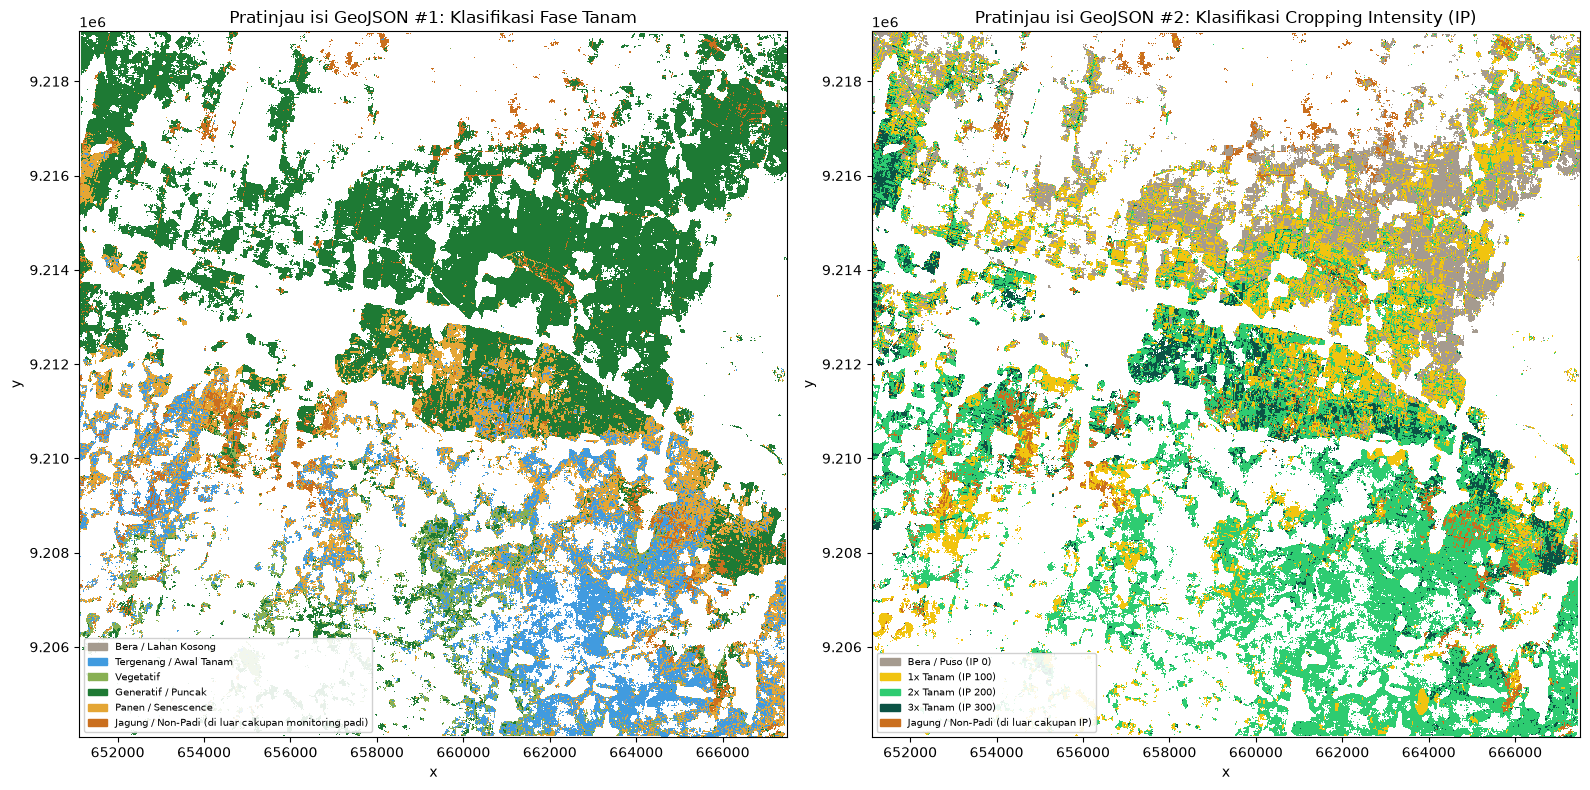


=> 3. Time Series Fenologi


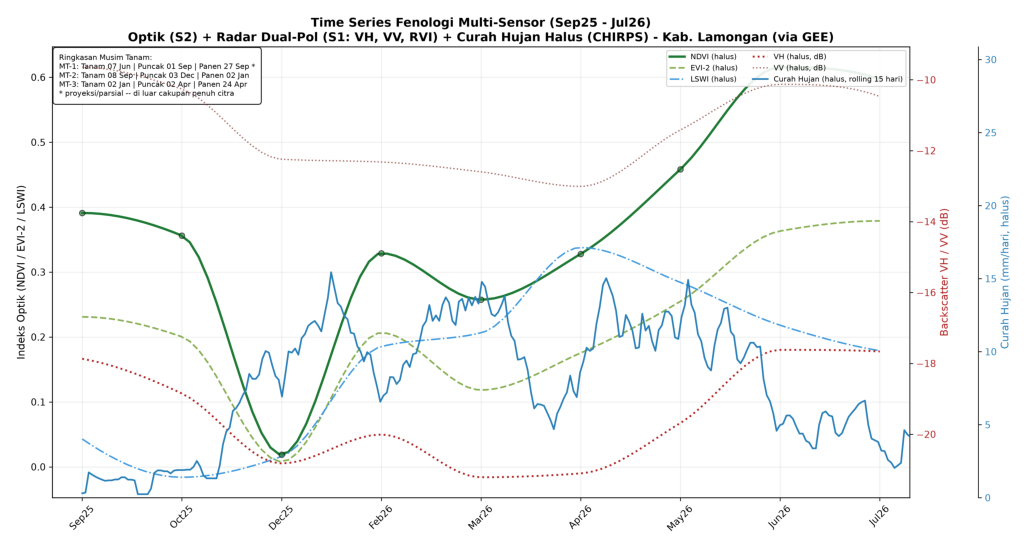


=> 4. Grafik Luas Fase Tanam


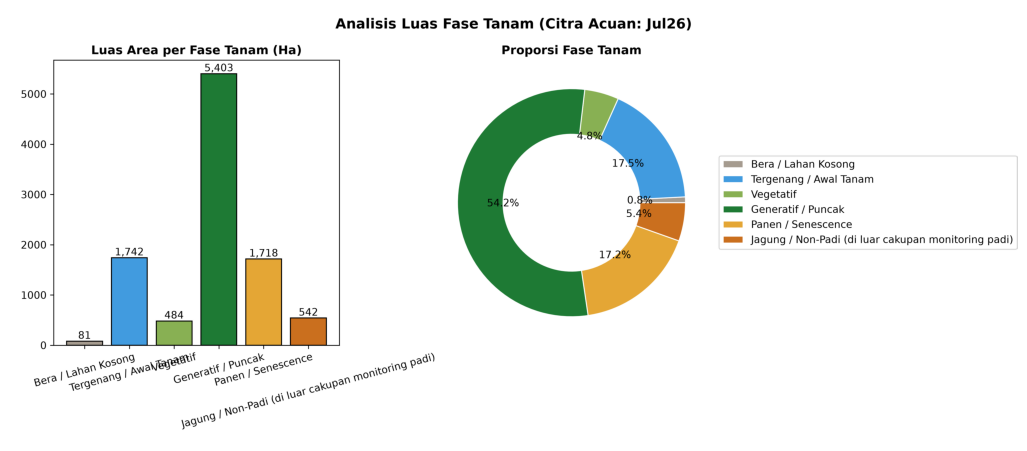


=> 5. Grafik Luas Cropping Intensity


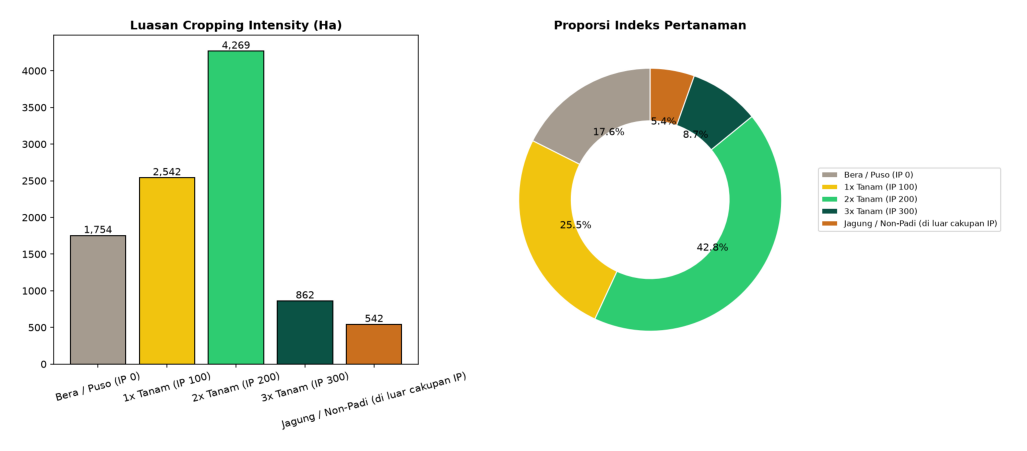

In [3]:
import os
import gc
import warnings
from datetime import datetime

import numpy as np
import pandas as pd
import xarray as xr
import rioxarray  # noqa: F401
import rasterio
from rasterio.features import shapes as rio_shapes
import geopandas as gpd
from shapely.geometry import box, shape as shapely_shape
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.offsetbox import AnchoredText
from scipy.signal import find_peaks
from scipy.interpolate import PchipInterpolator, interp1d

import ee
import geemap

warnings.filterwarnings("ignore")

# ==============================================================================
# 0. KONFIGURASI
# ==============================================================================
EE_PROJECT = "poetic-emblem-487109-t6"  # <-- GANTI dgn Project ID GEE/GCP Anda

EPSG_UTM = 32749
RESOLUSI_M = 10

RAW_DIR = "../../data/raw"
PROCESSED_DIR = "../../data/processed"
FIGURES_DIR = "../../results/figures/module_2"
os.makedirs(PROCESSED_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

MASK_SAWAH_PATH = os.path.join(PROCESSED_DIR, "Klasifikasi_Sawah.tif")
MODULE_DIR = os.path.join(PROCESSED_DIR, "module_2")
os.makedirs(MODULE_DIR, exist_ok=True)
FOLDER_CACHE = os.path.join(MODULE_DIR, "cache_komposit_bulanan_gee")
os.makedirs(FOLDER_CACHE, exist_ok=True)

# Window waktu (13 bulan) - Variabel dinamis akan digenerate saat runtime
JUMLAH_BULAN = 13

CLOUD_MAX_UTAMA = 20
CLOUD_MAX_FALLBACK = 40
CLOUD_MAX_DARURAT = 60
MIN_SCENE_PER_BULAN = 3      # target minimal scene S2 per bulan (bisa diubah ke 4)
ORBIT_PASS_S1 = "DESCENDING"

NODATA = 255
WARNA_JAGUNG = "#CA6F1E"   # cokelat-jingga "tongkol jagung" - sengaja beda dr palet padi

LABEL_FASE = {
    0: "Bera / Lahan Kosong", 1: "Tergenang / Awal Tanam",
    2: "Vegetatif", 3: "Generatif / Puncak", 4: "Panen / Senescence",
    5: "Jagung / Non-Padi (di luar cakupan monitoring padi)",
}
WARNA_FASE = {
    0: "#A59B8F", 1: "#419BDF", 2: "#88B053", 3: "#1E7A34", 4: "#E4A635",
    5: WARNA_JAGUNG,
}
LABEL_IP = {
    0: "Bera / Puso (IP 0)", 1: "1x Tanam (IP 100)",
    2: "2x Tanam (IP 200)", 3: "3x Tanam (IP 300)",
    4: "Jagung / Non-Padi (di luar cakupan IP)",
}
WARNA_IP = {
    0: "#A59B8F", 1: "#F1C40F", 2: "#2ECC71", 3: "#0B5345",
    4: WARNA_JAGUNG,
}

# --- Referensi fenologi padi: Fernandez-Jibaja et al. (2025) ---
FASE_FENOLOGI_DAS = {
    "Seedling": 11, "Tillering": 30, "Maximum Tillering": 48,
    "Inflorescence Emergence": 68, "Flowering": 86, "Ripening": 104,
}
DAS_ANCHOR_PUNCAK_NDVI = FASE_FENOLOGI_DAS["Flowering"]           # 86 HST
DAS_ANCHOR_PANEN = FASE_FENOLOGI_DAS["Ripening"] + 8               # 112 HST

JENDELA_KOREKSI_TANAM_HARI = 25    # Bouvet & Le Toan (2011)
JENDELA_KOREKSI_PANEN_HARI = 20
AMBANG_HUJAN_PENDUKUNG_MM = 60


# ==============================================================================
# 0A. INISIALISASI EARTH ENGINE & SETUP WAKTU
# ==============================================================================
def inisialisasi_gee():
    print("\n=== Inisialisasi Google Earth Engine ===")
    try:
        ee.Initialize(project=EE_PROJECT)
    except Exception:
        ee.Authenticate()
        ee.Initialize(project=EE_PROJECT)
    print("-> GEE siap dipakai.")

def setup_waktu_mundur():
    """Meminta input user untuk bulan target secara manual dan menarik data 13 bulan ke belakang."""
    print("\n=== PENGATURAN WAKTU ANALISIS ===")
    while True:
        # 1. Tampilkan instruksi secara terpisah agar rapi dan tidak terpotong
        print("Ketik bulan & tahun TERBARU untuk dianalisis (Format YYYY-MM, contoh: 2026-07):")

        # 2. Program akan berhenti di sini dan menunggu Anda MENGETIK tanggal secara manual
        tgl_input = input("-> ")

        try:
            target_date = pd.to_datetime(tgl_input)

            # Dengan parameter 'end', date_range akan menarik data mundur
            # freq='MS' berarti awal bulan (Month Start)
            daftar_bulan = pd.date_range(end=target_date.replace(day=1), periods=JUMLAH_BULAN, freq="MS")
            label_bulan = [d.strftime("%b%y") for d in daftar_bulan]

            print(f"-> Periode analisis ditarik {JUMLAH_BULAN} bulan ke belakang.")
            print(f"-> Mulai dari {label_bulan[0]} hingga {label_bulan[-1]}.")
            return daftar_bulan, label_bulan
        except Exception:
            print("Format salah! Harap ketik manual dalam format YYYY-MM (misal: 2026-07).\n")


# ==============================================================================
# 0B. EKSPOR GEOJSON - FORMAT OUTPUT UTK WEBGIS (tetap sama spt babak 3)
# ==============================================================================
def simpan_sebagai_geojson(da, path_out, label_dict, toleransi_simplify_m=15):
    arr = da.values.astype(np.uint8)
    transform = da.rio.transform()
    crs_asal = da.rio.crs
    mask_valid = arr != NODATA

    if not mask_valid.any():
        print(f"   [Peringatan] Tidak ada piksel valid utk diekspor -> {path_out} dilewati.")
        return None

    records = [
        {"kelas": int(val), "geometry": shapely_shape(geom)}
        for geom, val in rio_shapes(arr, mask=mask_valid, transform=transform, connectivity=4)
    ]

    gdf = gpd.GeoDataFrame(records, crs=crs_asal)
    gdf = gdf.dissolve(by="kelas", as_index=False)

    if toleransi_simplify_m and toleransi_simplify_m > 0:
        gdf["geometry"] = gdf["geometry"].simplify(toleransi_simplify_m, preserve_topology=True)

    luas_m2 = gdf.geometry.area
    gdf["luas_ha"] = (luas_m2 / 10000).round(2)
    gdf["label"] = gdf["kelas"].map(label_dict)

    gdf = gdf.to_crs("EPSG:4326")
    gdf.to_file(path_out, driver="GeoJSON")

    ukuran_kb = os.path.getsize(path_out) / 1024
    print(f"   -> Disimpan sbg GeoJSON (WebGIS-ready, {len(gdf)} fitur kelas, {ukuran_kb:,.0f} KB): {path_out}")
    return path_out


# ==============================================================================
# 1. BACA MASK SAWAH & BANGUN AOI (bbox WGS84 + ee.Geometry utk query GEE)
# ==============================================================================
def baca_mask_sawah():
    print("\n=== TAHAP 1: Membaca Mask Sawah ===")
    if not os.path.exists(MASK_SAWAH_PATH):
        raise FileNotFoundError(f"'{MASK_SAWAH_PATH}' tidak ditemukan.")
    da_mask = rioxarray.open_rasterio(MASK_SAWAH_PATH).squeeze(drop=True)
    n_sawah = int((da_mask.values == 1).sum())
    print(f"-> Mask terbaca. Piksel sawah: {n_sawah} ({n_sawah*(RESOLUSI_M**2)/10000:.2f} Ha)")

    bounds_utm = da_mask.rio.bounds()
    gdf = gpd.GeoDataFrame(geometry=[box(*bounds_utm)], crs=da_mask.rio.crs)
    bbox_wgs84 = tuple(gdf.to_crs("EPSG:4326").total_bounds)
    aoi_ee = ee.Geometry.Rectangle(list(bbox_wgs84))
    return da_mask, bbox_wgs84, aoi_ee


# ==============================================================================
# 2+3. CITRA BULANAN GABUNGAN (S2 optik + S1 radar/polarimetri + CHIRPS bulanan)
# ==============================================================================
def _mask_awan_scl(img):
    scl = img.select("SCL")
    bersih = scl.remap([3, 8, 9, 10], [0, 0, 0, 0], 1)
    return img.updateMask(bersih)


def _ke_linear_s1(img):
    vv_lin = ee.Image(10).pow(img.select("VV").divide(10)).rename("VV_lin")
    vh_lin = ee.Image(10).pow(img.select("VH").divide(10)).rename("VH_lin")
    return vv_lin.addBands(vh_lin)


def bangun_citra_bulanan_gabungan(aoi_ee, tanggal_awal_ts, min_scene=MIN_SCENE_PER_BULAN):
    awal = tanggal_awal_ts.strftime("%Y-%m-%d")
    akhir = (tanggal_awal_ts + pd.offsets.MonthEnd(0)).strftime("%Y-%m-%d")

    s2_col, cloud_max, n_s2 = None, CLOUD_MAX_DARURAT, 0
    for cmax in (CLOUD_MAX_UTAMA, CLOUD_MAX_FALLBACK, CLOUD_MAX_DARURAT):
        col = (ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
               .filterBounds(aoi_ee).filterDate(awal, akhir)
               .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", cmax)))
        n = col.size().getInfo()
        s2_col, cloud_max, n_s2 = col, cmax, n
        if n >= min_scene:
            break
    if n_s2 == 0:
        print(f"   [Peringatan] 0 scene S2 tersedia meski di ambang darurat {CLOUD_MAX_DARURAT}%.")
        return None, 0, 0, cloud_max
    if n_s2 < min_scene:
        print(f"   [Peringatan] Hanya {n_s2} scene S2 (target minimal {min_scene}) "
              f"meski sudah di ambang darurat {CLOUD_MAX_DARURAT}%.")

    s2_med = s2_col.map(_mask_awan_scl).median()
    b04 = s2_med.select("B4").divide(10000)
    b08 = s2_med.select("B8").divide(10000)
    b11 = s2_med.select("B11").divide(10000)
    ndvi = b08.subtract(b04).divide(b08.add(b04)).rename("NDVI")
    lswi = b08.subtract(b11).divide(b08.add(b11)).rename("LSWI")
    evi2 = b08.subtract(b04).multiply(2.5).divide(b08.add(b04.multiply(2.4)).add(1)).rename("EVI2")

    s1_col = (ee.ImageCollection("COPERNICUS/S1_GRD")
              .filterBounds(aoi_ee).filterDate(awal, akhir)
              .filter(ee.Filter.eq("instrumentMode", "IW"))
              .filter(ee.Filter.eq("orbitProperties_pass", ORBIT_PASS_S1))
              .filter(ee.Filter.listContains("transmitterReceiverPolarisation", "VV"))
              .filter(ee.Filter.listContains("transmitterReceiverPolarisation", "VH")))
    n_s1 = s1_col.size().getInfo()

    if n_s1 > 0:
        vv_db = s1_col.select("VV").median().rename("VV_db")
        vh_db = s1_col.select("VH").median().rename("VH_db")
        lin_col = s1_col.map(_ke_linear_s1)
        vv_lin_med = lin_col.select("VV_lin").median()
        vh_lin_med = lin_col.select("VH_lin").median()
        rvi = vh_lin_med.multiply(4).divide(vv_lin_med.add(vh_lin_med).add(1e-6)).rename("RVI")
        s1_bands = vh_db.addBands(vv_db).addBands(rvi)
    else:
        kosong = ee.Image.constant(0).rename("VH_db").updateMask(ee.Image(0))
        s1_bands = (kosong
                    .addBands(ee.Image.constant(0).rename("VV_db").updateMask(ee.Image(0)))
                    .addBands(ee.Image.constant(0).rename("RVI").updateMask(ee.Image(0))))

    rain_bulan = (ee.ImageCollection("UCSB-CHG/CHIRPS/DAILY")
                  .filterBounds(aoi_ee).filterDate(awal, akhir)
                  .sum().rename("RAIN"))

    gabungan = ndvi.addBands([lswi, evi2]).addBands(s1_bands).addBands(rain_bulan).clip(aoi_ee)
    return gabungan, n_s2, n_s1, cloud_max


DAFTAR_BAND_BULANAN = ["NDVI", "LSWI", "EVI2", "VH_db", "VV_db", "RVI", "RAIN"]

def unduh_citra_bulanan(gabungan_img, bbox_wgs84, label):
    region = ee.Geometry.Rectangle(list(bbox_wgs84))
    hasil = {}
    for nama_band in DAFTAR_BAND_BULANAN:
        path_cache = os.path.join(FOLDER_CACHE, f"komposit_{label}_{nama_band}.tif")
        if not os.path.exists(path_cache):
            geemap.ee_export_image(
                gabungan_img.select(nama_band),
                filename=path_cache,
                scale=RESOLUSI_M,
                crs=f"EPSG:{EPSG_UTM}",
                region=region,
                file_per_band=False,
            )
        if not os.path.exists(path_cache):
            print(f"   [Peringatan] Unduhan band {nama_band} utk {label} gagal.")
            return None
        hasil[nama_band] = rioxarray.open_rasterio(path_cache).squeeze(drop=True)
    return hasil


# ==============================================================================
# 4. CHIRPS HARIAN (utk kurva halus di grafik) - SATU permintaan server-side
# ==============================================================================
def kumpulkan_chirps_harian_gee(aoi_ee, tanggal_mulai, tanggal_akhir):
    print("\n=== TAHAP 2: Mengambil CHIRPS Harian dari GEE (UCSB-CHG/CHIRPS/DAILY) ===")
    col = (ee.ImageCollection("UCSB-CHG/CHIRPS/DAILY")
           .filterBounds(aoi_ee)
           .filterDate(tanggal_mulai.strftime("%Y-%m-%d"),
                       (tanggal_akhir + pd.Timedelta(days=1)).strftime("%Y-%m-%d")))

    def reduksi(img):
        rata2 = img.reduceRegion(
            reducer=ee.Reducer.mean(), geometry=aoi_ee, scale=5566, maxPixels=1e9
        ).get("precipitation")
        return ee.Feature(None, {"date": img.date().format("YYYY-MM-dd"), "precipitation": rata2})

    fc = ee.FeatureCollection(col.map(reduksi))
    data = fc.reduceColumns(ee.Reducer.toList(2), ["date", "precipitation"]).get("list").getInfo()

    df = pd.DataFrame(data, columns=["date", "precipitation"])
    df["date"] = pd.to_datetime(df["date"])
    df["precipitation"] = pd.to_numeric(df["precipitation"], errors="coerce").fillna(0)
    df = df.sort_values("date").reset_index(drop=True)
    print(f"-> CHIRPS harian selesai: {len(df)} hari diambil dlm SATU permintaan server-side.")
    return df


# ==============================================================================
# 5. BANGUN STACK TIME SERIES (13 bulan, dr GEE)
# ==============================================================================
def bangun_stack_time_series(aoi_ee, bbox_wgs84, da_mask, daftar_bulan, label_bulan):
    print("\n=== TAHAP 3: Mengunduh Komposit Bulanan Gabungan (GEE, 1 file/bulan) ===")

    list_ndvi, list_lswi, list_evi2 = [], [], []
    list_vh, list_vv, list_rvi, list_rain = [], [], [], []
    catatan, label_valid = [], []

    for tgl, label in zip(daftar_bulan, label_bulan):
        img, n_s2, n_s1, c_max = bangun_citra_bulanan_gabungan(aoi_ee, tgl)
        catatan.append({"Bulan": label, "N_Citra_S2": n_s2, "Ambang_Awan_%": c_max, "N_Citra_S1": n_s1})

        if n_s2 == 0:
            print(f"-> {label}: 0 citra S2. DISKIP.")
            continue

        da_bulan = unduh_citra_bulanan(img, bbox_wgs84, label)
        if da_bulan is None:
            print(f"   [Peringatan] Unduhan {label} gagal, dilewati.")
            continue

        print(f"-> {label}: S2={n_s2} citra (awan<{c_max}%, target min {MIN_SCENE_PER_BULAN}), "
              f"S1={n_s1} citra [7 unduhan per-band]")
        label_valid.append(label)

        def ambil(nm):
            return da_bulan[nm].rio.reproject_match(da_mask)

        list_ndvi.append(ambil("NDVI"))
        list_lswi.append(ambil("LSWI"))
        list_evi2.append(ambil("EVI2"))
        list_vh.append(ambil("VH_db"))
        list_vv.append(ambil("VV_db"))
        list_rvi.append(ambil("RVI"))
        list_rain.append(ambil("RAIN"))

        del da_bulan
        gc.collect()

    if not label_valid:
        raise RuntimeError(
            "Tidak ada satu bulan pun yang berhasil diunduh dari GEE - cek pesan "
            "[Peringatan] di atas (mis. kuota/limit ukuran unduhan, koneksi, atau "
            "AOI di luar cakupan koleksi)."
        )

    tanggal_mulai_chirps = daftar_bulan[0]
    tanggal_akhir_chirps = daftar_bulan[-1] + pd.offsets.MonthEnd(0)
    df_rain_daily = kumpulkan_chirps_harian_gee(aoi_ee, tanggal_mulai_chirps, tanggal_akhir_chirps)

    def aman_concat(daftar_da):
        return xr.concat(daftar_da, dim="waktu", coords="minimal", compat="override").assign_coords(waktu=label_valid)

    return (
        aman_concat(list_ndvi),
        aman_concat(list_lswi),
        aman_concat(list_evi2),
        aman_concat(list_vh),
        aman_concat(list_vv),
        aman_concat(list_rvi),
        aman_concat(list_rain),
        pd.DataFrame(catatan), label_valid, df_rain_daily,
    )


# ==============================================================================
# 5B. PEMBEDA KOMODITAS PADI vs JAGUNG (SALIN PERSIS dr babak 2/3, poin #4)
# ==============================================================================
def identifikasi_piksel_padi(ndvi_stack, lswi_stack, vh_stack, da_mask):
    print("\n=== Pembeda Komoditas: Padi vs Jagung (berbasis genangan, per piksel) ===")
    ndvi_v = ndvi_stack.values
    lswi_v = lswi_stack.values
    vh_v = vh_stack.values
    mask_sawah = (da_mask.values == 1)
    n_bulan = ndvi_v.shape[0]

    with np.errstate(invalid="ignore"):
        ndvi_max = np.nanmax(ndvi_v, axis=0)
        ndvi_isi = np.nan_to_num(ndvi_v, nan=-99.0)
        idx_puncak_per_piksel = np.nanargmax(ndvi_isi, axis=0)

    siklus_aktif = mask_sawah & (ndvi_max >= 0.35)

    if np.isfinite(vh_v[:, mask_sawah]).any():
        ambang_vh_genangan = np.nanpercentile(vh_v[:, mask_sawah], 30)
    else:
        ambang_vh_genangan = np.nan

    genangan_terdeteksi = np.zeros(mask_sawah.shape, dtype=bool)
    for t in range(n_bulan):
        sebelum_puncak = (t < idx_puncak_per_piksel)
        bukti_optik = (lswi_v[t] >= (ndvi_v[t] - 0.05))
        if t + 1 < n_bulan and np.isfinite(ambang_vh_genangan):
            bukti_radar = (
                np.isfinite(vh_v[t]) & (vh_v[t] <= ambang_vh_genangan) &
                np.isfinite(vh_v[t + 1]) & (vh_v[t + 1] > vh_v[t])
            )
        else:
            bukti_radar = np.zeros(mask_sawah.shape, dtype=bool)
        genangan_terdeteksi |= sebelum_puncak & (bukti_optik | bukti_radar)

    mask_padi = siklus_aktif & genangan_terdeteksi
    mask_jagung = siklus_aktif & ~genangan_terdeteksi

    n_padi, n_jagung = int(mask_padi.sum()), int(mask_jagung.sum())
    print(f"-> PADI (genangan terdeteksi): {n_padi} piksel ({n_padi*(RESOLUSI_M**2)/10000:.2f} Ha)")
    print(f"-> JAGUNG/lahan kering lain (siklus aktif, TANPA genangan): {n_jagung} piksel ({n_jagung*(RESOLUSI_M**2)/10000:.2f} Ha)")
    print("-> Piksel jagung diberi kelas terpisah, TIDAK ikut dihitung sbg statistik padi.")
    return mask_padi, mask_jagung


# ==============================================================================
# 6. KLASIFIKASI FASE TANAM TERKINI (SALIN PERSIS dr babak 1-3)
# ==============================================================================
def klasifikasikan_fase_tanam(ndvi_stack, lswi_stack, evi2_stack, vh_stack, rvi_stack, rain_stack, mask_padi, mask_jagung):
    print("\n=== TAHAP 4: Klasifikasi Fase Tanam (Optik + Radar + Polarimetri Dual-Pol + Hujan) ===")
    ndvi_v, lswi_v, evi2_v, vh_v, rvi_v, rain_v = (
        s.values for s in (ndvi_stack, lswi_stack, evi2_stack, vh_stack, rvi_stack, rain_stack)
    )
    mask_valid = mask_padi

    def posisi_relatif(vals):
        with np.errstate(invalid="ignore"):
            vmin, vmax = np.nanmin(vals, axis=0), np.nanmax(vals, axis=0)
        rentang = np.where((vmax - vmin) > 1e-6, vmax - vmin, 1e-6)
        return (vals[-1] - vmin) / rentang, vmax, vmin

    pos_ndvi, ndvi_max, _ = posisi_relatif(ndvi_v)
    pos_evi2, _, _ = posisi_relatif(evi2_v)
    posisi_gab = np.nanmean(np.stack([pos_ndvi, pos_evi2]), axis=0)

    ndvi_now, ndvi_prev = ndvi_v[-1], ndvi_v[-2]
    lswi_now, vh_now, rvi_now, rain_now = lswi_v[-1], vh_v[-1], rvi_v[-1], rain_v[-1]
    slope = ndvi_now - ndvi_prev
    valid = mask_valid & ~np.isnan(ndvi_now) & ~np.isnan(lswi_now)

    tanpa_siklus_aktif = valid & (ndvi_max < 0.35)
    ada_siklus_aktif = valid & ~tanpa_siklus_aktif

    flood_optic = (lswi_now >= ndvi_now) & (posisi_gab <= 0.35)

    if np.isfinite(vh_now).any():
        ambang_vh = np.nanpercentile(vh_now[mask_valid & np.isfinite(vh_now)], 20)
        flood_radar_vh = np.isfinite(vh_now) & (vh_now <= ambang_vh) & (posisi_gab <= 0.5)
    else:
        flood_radar_vh = np.zeros_like(flood_optic, dtype=bool)

    if np.isfinite(rvi_now).any():
        ambang_rvi = np.nanpercentile(rvi_now[mask_valid & np.isfinite(rvi_now)], 25)
        flood_radar_rvi = np.isfinite(rvi_now) & (rvi_now <= ambang_rvi) & (posisi_gab <= 0.5)
    else:
        flood_radar_rvi = np.zeros_like(flood_optic, dtype=bool)

    flood_radar = flood_radar_vh | flood_radar_rvi

    if np.isfinite(rain_now).any():
        flood_rain = np.isfinite(rain_now) & (rain_now > 100.0) & (posisi_gab <= 0.35)
    else:
        flood_rain = np.zeros_like(flood_optic, dtype=bool)

    bera_datar = tanpa_siklus_aktif & (lswi_now < ndvi_now)
    genangan_datar = tanpa_siklus_aktif & (lswi_now >= ndvi_now)

    bera_normal = ada_siklus_aktif & (posisi_gab <= 0.25) & (lswi_now < ndvi_now) & ~flood_radar & ~flood_rain
    genangan_normal = ada_siklus_aktif & (flood_optic | flood_radar | flood_rain)

    generatif = ada_siklus_aktif & (posisi_gab >= 0.75) & ~genangan_normal
    sisa = ada_siklus_aktif & ~bera_normal & ~genangan_normal & ~generatif
    vegetatif = sisa & (slope >= 0)
    panen = sisa & (slope < 0)

    fase = np.full(ndvi_now.shape, NODATA, dtype=np.uint8)
    fase[bera_datar] = 0; fase[bera_normal] = 0
    fase[genangan_datar] = 1; fase[genangan_normal] = 1
    fase[vegetatif] = 2; fase[generatif] = 3; fase[panen] = 4
    fase[mask_jagung] = 5

    n_dikonfirmasi_rvi = int(np.sum(flood_radar_rvi & ~flood_radar_vh & mask_valid))
    print(f"   [Info polarimetri] {n_dikonfirmasi_rvi} piksel genangan terdeteksi TAMBAHAN "
          f"oleh RVI yang sebelumnya terlewat oleh VH-amplitudo saja.")

    kelas_tersedia = sorted(np.unique(fase[fase != NODATA]).tolist())
    for k in kelas_tersedia:
        n = int((fase == k).sum())
        print(f"-> {LABEL_FASE[k]}: {n} piksel ({n*(RESOLUSI_M**2)/10000:.2f} Ha)")
    return fase, kelas_tersedia


# ==============================================================================
# 7. TIME SERIES AGREGAT, SMOOTHING, & DETEKSI MULTI-MUSIM (SALIN PERSIS)
# ==============================================================================
def bangun_time_series_agregat(ndvi_stack, lswi_stack, evi2_stack, vh_stack, vv_stack, rvi_stack, mask_padi):
    def rata(stack):
        return np.nanmean(np.where(mask_padi, stack.values, np.nan), axis=(1, 2))
    return (rata(ndvi_stack), rata(lswi_stack), rata(evi2_stack),
            rata(vh_stack), rata(vv_stack), rata(rvi_stack))


def haluskan_kurva(nilai, titik_per_bulan=10):
    """
    [PERBAIKAN #1 - AKAR MASALAH] Sebelumnya fungsi ini memakai
    CubicSpline(bc_type="natural"), yang pada data BULANAN yang jarang (13 titik)
    dan naik-turun tajam (mis. NDVI anjlok dari ~0.36 ke ~0.02 dlm 1-2 bulan)
    sangat rawan "overshoot/ringing": spline melengkung melewati rentang data asli
    dan bisa memunculkan puncak/lembah PALSU yang secara visual di kurva halus
    terlihat wajar, tapi tidak merepresentasikan pola tutupan vegetasi sebenarnya.
    Inilah penyebab utama kenapa "Puncak" MT-1 sebelumnya justru jatuh di sekitar
    titik minimum NDVI (bkn di bulan Feb saat NDVI benar2 memuncak).

    PchipInterpolator (Piecewise Cubic Hermite) bersifat "shape-preserving": ia
    tidak akan membuat kurva melampaui rentang nilai naik/turun asli antar dua
    titik data, sehingga tidak menghasilkan ekstrem palsu. Ini standar yg lbh
    tepat utk time series citra bulanan yg jarang & bernoise spt kasus ini.

    [PERBAIKAN #4a] extrapolate=True sebelumnya dipakai scr default. Jika stack
    bulanan (ndvi_mean dkk) punya NaN di ujung deret (mis. bulan terakhir gagal
    diunduh / seluruh piksel padi tertutup awan bulan itu), PCHIP akan
    mengekstrapolasi kurva ke luar rentang data asli memakai polinomial kubik
    turunan-terakhir, yg pada praktiknya bisa "meledak" (nilai jauh di luar
    rentang NDVI/EVI2/LSWI yg masuk akal). Nilai ekstrapolasi yg meledak ini lalu
    mencemari statistik "rentang" (nanmax-nanmin) yg dipakai deteksi_puncak_lembah
    utk menentukan ambang prominence -> ambang jadi jauh lbh besar dr semestinya
    -> puncak/lembah asli di TENGAH window jadi tak lolos filter & tak terdeteksi.
    Diperbaiki dgn extrapolate=False (tak menembak nilai di luar data asli) lalu
    menahan nilai konstan (flat) di kedua ujung -- lbh aman & scr fisik lbh jujur
    ("tanpa citra baru, asumsikan kondisi terakhir yg diketahui").
    """
    n = len(nilai); x = np.arange(n); idx_valid = ~np.isnan(nilai)
    if idx_valid.sum() < 4:
        f = interp1d(x[idx_valid], nilai[idx_valid], kind="linear", fill_value="extrapolate")
        x_halus = np.linspace(0, n - 1, n * titik_per_bulan)
        return x_halus, f(x_halus)

    x_valid = x[idx_valid]
    f = PchipInterpolator(x_valid, nilai[idx_valid], extrapolate=False)
    x_halus = np.linspace(0, n - 1, n * titik_per_bulan)
    y_halus = f(x_halus)

    # Tahan (flat) nilai di luar rentang data asli, bukan diekstrapolasi bebas.
    y_valid_awal, y_valid_akhir = nilai[idx_valid][0], nilai[idx_valid][-1]
    y_halus = np.where(x_halus < x_valid[0], y_valid_awal, y_halus)
    y_halus = np.where(x_halus > x_valid[-1], y_valid_akhir, y_halus)
    return x_halus, y_halus


def haluskan_hujan(df_rain, window_hari=15):
    df = df_rain.sort_values("date").reset_index(drop=True)
    df["precipitation_halus"] = df["precipitation"].rolling(
        window=window_hari, center=True, min_periods=1
    ).mean()
    return df


def _kelompokkan_ekstrem_dekat(idx_arr, y, jarak_sample, mode):
    """Gabungkan titik ekstrem sejenis (puncak/lembah) yg jaraknya < jarak_sample,
    menyisakan yg paling ekstrem dr tiap kelompok. Dipakai oleh deteksi_puncak_lembah
    (lihat PERBAIKAN #4b) supaya wiggle kecil hasil smoothing tak dihitung ganda."""
    if len(idx_arr) < 2:
        return idx_arr
    hasil = [idx_arr[0]]
    for i in idx_arr[1:]:
        if i - hasil[-1] < jarak_sample:
            lebih_ekstrem = (y[i] > y[hasil[-1]]) if mode == "puncak" else (y[i] < y[hasil[-1]])
            if lebih_ekstrem:
                hasil[-1] = i
        else:
            hasil.append(i)
    return np.array(hasil, dtype=int)


def _ekstrem_lokal_sederhana(y, jarak_sample):
    """[PERBAIKAN #4b] Deteksi SEMUA titik balik arah (puncak & lembah) murni
    berdasar perubahan tanda turunan pertama -- tanpa syarat prominence topografis
    scipy. Plateau (turunan persis 0, jarang terjadi stlh PCHIP) diisi dgn tanda
    sblmnya spy tak memicu deteksi ganda."""
    d = np.diff(y)
    tanda = np.sign(d)
    for i in range(1, len(tanda)):
        if tanda[i] == 0:
            tanda[i] = tanda[i - 1]
    puncak, lembah = [], []
    for i in range(1, len(tanda)):
        if tanda[i - 1] > 0 and tanda[i] < 0:
            puncak.append(i)
        elif tanda[i - 1] < 0 and tanda[i] > 0:
            lembah.append(i)
    puncak = _kelompokkan_ekstrem_dekat(np.array(puncak, dtype=int), y, jarak_sample, "puncak")
    lembah = _kelompokkan_ekstrem_dekat(np.array(lembah, dtype=int), y, jarak_sample, "lembah")
    return puncak, lembah


def deteksi_puncak_lembah(x_halus, y_halus, ambang_ndvi_aktif=0.30, jarak_minimum_hari=60,
                           ambang_amplitudo_rel=0.10, ambang_amplitudo_abs=0.05):
    """
    [PERBAIKAN #4 - MULTI-MUSIM] Versi SEBELUMNYA memakai scipy.signal.find_peaks
    dgn `prominence` global (topografis): prominence sebuah puncak dihitung relatif
    thd titik TERTINGGI di antara 2 lembah pembatas di kiri & kanannya -- termasuk
    kalau lembah pembatas itu sebenarnya jauh, di seberang puncak lain yg JAUH LEBIH
    TINGGI. Akibatnya: puncak awal/pertengahan musim yg VALID (mis. puncak NDVI
    bulan Feb, fase generatif musim ke-1) bisa "ditenggelamkan" & gagal lolos
    ambang prominence HANYA karena belakangan (bulan Jun-Jul, musim berikutnya)
    NDVI naik lebih tinggi lagi. Inilah sebab utama skrip sebelumnya cuma
    berhasil mengenali SATU musim tanam (biasanya cuma musim yg lg berjalan di
    ujung window) walau grafiknya scr visual jelas py >1 siklus naik-turun.

    Perbaikannya: ganti definisi "signifikan" dari prominence topografis global
    -> AMPLITUDO LOKAL thd tetangga ekstrem terdekat (kiri & kanan), diambil yg
    PALING BESAR (bukan yg terkecil spt prominence klasik). Artinya: selama
    sebuah puncak py kenaikan tajam dr lembah SEBELUMNYA *atau* penurunan tajam
    ke lembah SESUDAHNYA (salah satu saja cukup), ia dianggap 1 siklus tanam yg
    sah -- tak peduli ada puncak lain yg lebih tinggi di bulan2 berikutnya.
    Ambang minimal (`ambang_amplitudo_rel`/`_abs`) & jarak minimum antar ekstrem
    (`jarak_minimum_hari`) tetap dipertahankan spy noise kecil tak ikut terhitung.

    Dua kondisi batas window (puncak_di_awal, musim_belum_puncak) dr versi
    sebelumnya TETAP dipertahankan persis spt semula.
    """
    rentang = np.nanmax(y_halus) - np.nanmin(y_halus)
    ambang_amp = max(rentang * ambang_amplitudo_rel, ambang_amplitudo_abs)

    if len(x_halus) > 1:
        sample_per_hari = (len(x_halus) - 1) / ((x_halus[-1] - x_halus[0]) * 30.4375)
    else:
        sample_per_hari = 1
    jarak_sample = max(int(jarak_minimum_hari * sample_per_hari), 1)

    puncak_kandidat, lembah_kandidat = _ekstrem_lokal_sederhana(y_halus, jarak_sample)

    # Gabungkan jd 1 urutan berselang-seling utk mencari tetangga kiri/kanan tiap titik
    semua = sorted([(int(i), "puncak") for i in puncak_kandidat] +
                    [(int(i), "lembah") for i in lembah_kandidat])

    def nilai_tetangga(pos):
        kiri = y_halus[semua[pos - 1][0]] if pos - 1 >= 0 else y_halus[0]
        kanan = y_halus[semua[pos + 1][0]] if pos + 1 < len(semua) else y_halus[-1]
        return kiri, kanan

    puncak, lembah = [], []
    for pos, (i, tipe) in enumerate(semua):
        kiri, kanan = nilai_tetangga(pos)
        if tipe == "puncak":
            amplitudo = max(y_halus[i] - kiri, y_halus[i] - kanan)
            if amplitudo >= ambang_amp:
                puncak.append(i)
        else:
            amplitudo = max(kiri - y_halus[i], kanan - y_halus[i])
            if amplitudo >= ambang_amp:
                lembah.append(i)
    puncak, lembah = np.array(sorted(puncak), dtype=int), np.array(sorted(lembah), dtype=int)

    # --- Boundary awal: nilai tinggi & langsung menurun sejak titik pertama ---
    puncak_di_awal = False
    if y_halus[0] >= ambang_ndvi_aktif and y_halus[0] > y_halus[1] and (len(puncak) == 0 or 0 not in puncak):
        puncak = np.insert(puncak, 0, 0)
        puncak_di_awal = True

    # --- Boundary akhir: kurva masih naik hingga titik terakhir ---
    musim_belum_puncak = bool(y_halus[-1] > y_halus[-2])

    if y_halus[0] <= np.nanmin(y_halus) + 1e-9 and (len(lembah) == 0 or 0 not in lembah):
        lembah = np.append(lembah, 0)
    if y_halus[-1] <= np.nanmin(y_halus) + 1e-9 and (len(lembah) == 0 or (len(y_halus) - 1) not in lembah):
        lembah = np.append(lembah, len(y_halus) - 1)

    return np.sort(puncak), np.sort(lembah), puncak_di_awal, musim_belum_puncak


def _cari_ekstrem_terdekat(x_halus, indeks_ekstrem, idx_acuan, jendela_hari):
    jendela_bulan = jendela_hari / 30.4375
    kandidat = [i for i in indeks_ekstrem if abs(x_halus[i] - idx_acuan) <= jendela_bulan]
    if not kandidat:
        return None
    return min(kandidat, key=lambda i: abs(x_halus[i] - idx_acuan))


def estimasi_tanggal_kunci(daftar_bulan, x_ndvi, x_vh, lembah_vh, puncak_ndvi, lembah_ndvi, df_rain_halus,
                            puncak_di_awal=False, musim_belum_puncak=False):
    """
    [PERBAIKAN #3] Fungsi ini kini dipanggil dgn SEMUA puncak yg terdeteksi oleh
    deteksi_puncak_lembah (bisa lebih dari satu -> otomatis menghasilkan
    MT-1, MT-2, dst), ditambah 2 skenario musim yg terpotong di tepi window:

    - puncak_di_awal=True -> puncak pertama (idx 0) sebenarnya di LUAR window
      (sebelum citra tersedia). Tanggal tanam yg dihitung mundur dari puncak
      ini diberi catatan eksplisit sbg proyeksi/tdk pasti, BUKAN dianggap
      hasil deteksi langsung.
    - musim_belum_puncak=True -> ditambahkan SATU entri musim baru "berjalan"
      yang tanggal tanamnya diambil dari lembah NDVI terakhir (setelah puncak
      paling akhir yg terdeteksi), lalu tgl puncak & panen-nya DIPROYEKSIKAN
      maju memakai anchor DAS yg sama, dgn catatan bahwa itu belum
      terkonfirmasi citra (perlu window bulan berikutnya utk memastikan).
    """
    def idx_ke_tanggal(idx_pecahan):
        return daftar_bulan[0] + pd.Timedelta(days=idx_pecahan * 30.4375)

    def tanggal_ke_idx(tgl):
        return (tgl - daftar_bulan[0]).days / 30.4375

    musim_list = []
    for urutan, idx_puncak in enumerate(puncak_ndvi):
        tgl_puncak = idx_ke_tanggal(x_ndvi[idx_puncak])

        catatan_batas = None
        if puncak_di_awal and idx_puncak == puncak_ndvi[0] and idx_puncak == 0:
            catatan_batas = ("Puncak fenologi diperkirakan terjadi SEBELUM awal citra "
                              "(NDVI sudah tinggi & langsung menurun sejak bulan pertama "
                              "window) -> tanggal tanam di bawah ini hasil proyeksi mundur, "
                              "bukan deteksi langsung dari citra.")

        tgl_tanam_acuan = tgl_puncak - pd.Timedelta(days=DAS_ANCHOR_PUNCAK_NDVI)
        tgl_panen_acuan = tgl_puncak + pd.Timedelta(days=DAS_ANCHOR_PANEN - DAS_ANCHOR_PUNCAK_NDVI)

        idx_acuan_tanam = tanggal_ke_idx(tgl_tanam_acuan)
        idx_terpilih_tanam = _cari_ekstrem_terdekat(x_vh, list(lembah_vh), idx_acuan_tanam, JENDELA_KOREKSI_TANAM_HARI)
        if idx_terpilih_tanam is not None and idx_acuan_tanam >= 0:
            tgl_tanam = idx_ke_tanggal(x_vh[idx_terpilih_tanam])
            metode_tanam = "Radar VH (terkoreksi)"
        else:
            tgl_tanam = tgl_tanam_acuan
            metode_tanam = ("Proyeksi mundur -- di luar cakupan citra" if idx_acuan_tanam < 0
                             else "DAS Fernandez-Jibaja (fallback, tdk ada palung VH jelas)")

        delta_tanam = tgl_tanam - tgl_tanam_acuan
        tgl_panen_bergeser = tgl_panen_acuan + delta_tanam
        tahap_antara = {nama: tgl_tanam + pd.Timedelta(days=das) for nama, das in FASE_FENOLOGI_DAS.items()}

        idx_acuan_panen = tanggal_ke_idx(tgl_panen_bergeser)
        kandidat_lembah_ndvi = [l for l in lembah_ndvi if l > idx_puncak]
        idx_terpilih_panen = _cari_ekstrem_terdekat(x_ndvi, kandidat_lembah_ndvi, idx_acuan_panen, JENDELA_KOREKSI_PANEN_HARI)
        if idx_terpilih_panen is not None:
            tgl_panen = idx_ke_tanggal(x_ndvi[idx_terpilih_panen])
            metode_panen = "Senescence NDVI (terkoreksi)"
        else:
            tgl_panen = tgl_panen_bergeser
            metode_panen = "DAS Fernandez-Jibaja (fallback, tdk ada lembah NDVI jelas)"

        catatan_hujan = "Data hujan tdk tersedia"
        if df_rain_halus is not None and not df_rain_halus.empty:
            jendela = (df_rain_halus["date"] >= tgl_tanam - pd.Timedelta(days=10)) & \
                      (df_rain_halus["date"] <= tgl_tanam + pd.Timedelta(days=10))
            akumulasi = df_rain_halus.loc[jendela, "precipitation_halus"].sum()
            if akumulasi >= AMBANG_HUJAN_PENDUKUNG_MM:
                catatan_hujan = f"Didukung curah hujan (akumulasi ~{akumulasi:.0f} mm/20hr di sekitar tgl tanam)"
            else:
                catatan_hujan = f"Tdk ada dukungan hujan jelas (~{akumulasi:.0f} mm/20hr)"

        musim_list.append({
            "mt_label": f"MT-{urutan+1}", "planting": tgl_tanam, "peak": tgl_puncak,
            "harvest": tgl_panen, "acuan": "Fernandez-Jibaja et al. (2025) + koreksi VH/NDVI",
            "metode_tanam": metode_tanam, "metode_panen": metode_panen,
            "catatan_hujan": catatan_hujan, "tahap_antara": tahap_antara,
            "status": "lengkap" if not catatan_batas else "parsial_sebelum_window",
            "catatan_batas": catatan_batas,
        })

    # --- Musim yang SEDANG BERLANGSUNG di ujung akhir window (belum mencapai puncak) ---
    if musim_belum_puncak:
        lembah_setelah_puncak_terakhir = [
            l for l in lembah_ndvi if (len(puncak_ndvi) == 0 or l > puncak_ndvi[-1])
        ]
        if lembah_setelah_puncak_terakhir:
            idx_tanam_proyeksi = lembah_setelah_puncak_terakhir[-1]
            tgl_tanam_proyeksi = idx_ke_tanggal(x_ndvi[idx_tanam_proyeksi])
            metode_tanam_proyeksi = "Lembah NDVI terakhir (estimasi awal musim yg sedang berjalan)"
        else:
            tgl_tanam_proyeksi = idx_ke_tanggal(x_ndvi[-1]) - pd.Timedelta(days=45)
            metode_tanam_proyeksi = "Proyeksi kasar (tdk ada lembah NDVI terdeteksi sblm titik akhir)"

        tgl_puncak_proyeksi = tgl_tanam_proyeksi + pd.Timedelta(days=DAS_ANCHOR_PUNCAK_NDVI)
        tgl_panen_proyeksi = tgl_tanam_proyeksi + pd.Timedelta(days=DAS_ANCHOR_PANEN)
        tahap_antara_proyeksi = {nama: tgl_tanam_proyeksi + pd.Timedelta(days=das)
                                  for nama, das in FASE_FENOLOGI_DAS.items()}

        musim_list.append({
            "mt_label": f"MT-{len(musim_list)+1} (berjalan)",
            "planting": tgl_tanam_proyeksi, "peak": tgl_puncak_proyeksi,
            "harvest": tgl_panen_proyeksi,
            "acuan": "Proyeksi DAS Fernandez-Jibaja et al. (2025) -- BELUM terkonfirmasi citra",
            "metode_tanam": metode_tanam_proyeksi,
            "metode_panen": "Proyeksi (fase puncak/panen di luar cakupan citra saat ini)",
            "catatan_hujan": "Belum dievaluasi (musim masih berjalan)",
            "tahap_antara": tahap_antara_proyeksi,
            "status": "berjalan_proyeksi",
            "catatan_batas": ("Kurva NDVI masih naik hingga bulan terakhir window citra -> "
                               "puncak & tanggal panen di atas adalah PROYEKSI, perlu "
                               "dikonfirmasi ulang dgn citra bulan-bulan berikutnya."),
        })

    return musim_list


def deteksi_periode_double_bounce(vv_mean, rvi_mean, lswi_mean):
    n = len(vv_mean)
    indikasi = np.zeros(n, dtype=bool)
    ambang_rvi = np.nanmedian(rvi_mean)
    ambang_lswi = np.nanmedian(lswi_mean)
    for i in range(1, n):
        vv_naik = (not np.isnan(vv_mean[i])) and (not np.isnan(vv_mean[i - 1])) and (vv_mean[i] > vv_mean[i - 1])
        rvi_rendah = (not np.isnan(rvi_mean[i])) and (rvi_mean[i] <= ambang_rvi)
        lswi_tinggi = (not np.isnan(lswi_mean[i])) and (lswi_mean[i] >= ambang_lswi)
        indikasi[i] = vv_naik and rvi_rendah and lswi_tinggi
    return indikasi


# ==============================================================================
# 8. GRAFIK TIME SERIES (SALIN PERSIS dr babak 3)
# ==============================================================================
def grafik_time_series(daftar_bulan, label_bulan, ndvi_mean, lswi_mean, evi2_mean,
                       vh_mean, vv_mean, rvi_mean, df_rain):
    print("\n=== TAHAP 5: Membuat Grafik Time Series ===")
    x_ndvi, y_ndvi = haluskan_kurva(ndvi_mean)
    x_lswi, y_lswi = haluskan_kurva(lswi_mean)
    x_evi2, y_evi2 = haluskan_kurva(evi2_mean)
    x_vh, y_vh = haluskan_kurva(vh_mean)
    x_vv, y_vv = haluskan_kurva(vv_mean)
    x_rvi, y_rvi = haluskan_kurva(rvi_mean)

    puncak_ndvi, lembah_ndvi, puncak_di_awal, musim_belum_puncak = deteksi_puncak_lembah(x_ndvi, y_ndvi)
    _, lembah_vh, _, _ = deteksi_puncak_lembah(x_vh, y_vh)
    df_rain_halus = haluskan_hujan(df_rain, window_hari=15)

    musim_list = estimasi_tanggal_kunci(
        daftar_bulan, x_ndvi, x_vh, lembah_vh, puncak_ndvi, lembah_ndvi, df_rain_halus,
        puncak_di_awal=puncak_di_awal, musim_belum_puncak=musim_belum_puncak
    )
    indikasi_db = deteksi_periode_double_bounce(vv_mean, rvi_mean, lswi_mean)

    print(f"   -> {len(musim_list)} musim tanam teridentifikasi dlm window ini.")
    print("   Rincian tahap fenologi per musim (Fernandez-Jibaja et al. 2025 + koreksi sensor, HST):")
    for m in musim_list:
        rincian = ", ".join(f"{n} {t:%d %b}" for n, t in m["tahap_antara"].items())
        print(f"   {m['mt_label']}: Tanam {m['planting']:%d %b %y} [{m['metode_tanam']}]")
        print(f"           {rincian}")
        print(f"           Panen {m['harvest']:%d %b %y} [{m['metode_panen']}] | {m['catatan_hujan']}")
        if m.get("catatan_batas"):
            print(f"           [!] {m['catatan_batas']}")

    fig, ax1 = plt.subplots(figsize=(15, 8))

    ax1.plot(x_ndvi, y_ndvi, color="#1E7A34", lw=2.5, label="NDVI (halus)")
    ax1.scatter(range(len(ndvi_mean)), ndvi_mean, color="#1E7A34", s=35, zorder=5, edgecolor="black", alpha=0.6)
    ax1.plot(x_evi2, y_evi2, color="#88B053", lw=1.8, ls="--", label="EVI-2 (halus)")
    ax1.plot(x_lswi, y_lswi, color="#419BDF", lw=1.6, ls="-.", label="LSWI (halus)")
    ax1.set_ylabel("Indeks Optik (NDVI / EVI-2 / LSWI)", fontsize=11)
    ax1.set_xticks(range(len(label_bulan))); ax1.set_xticklabels(label_bulan, rotation=45)
    ax1.set_xlim(-0.3, len(label_bulan) - 0.7)
    ax1.grid(alpha=0.25)

    ax2 = ax1.twinx()
    ax2.plot(x_vh, y_vh, color="#B22222", lw=2.0, ls=":", label="VH (halus, dB)")
    ax2.plot(x_vv, y_vv, color="#7B241C", lw=1.4, ls=":", alpha=0.7, label="VV (halus, dB)")
    ax2.set_ylabel("Backscatter VH / VV (dB)", color="#B22222", fontsize=11)
    ax2.tick_params(axis="y", labelcolor="#B22222")

    g3, l3 = [], []
    if not df_rain.empty:
        ax3 = ax1.twinx()
        ax3.spines["right"].set_position(("axes", 1.08))
        def tgl_ke_x(t): return (t - daftar_bulan[0]).days / 30.4375
        x_rain = [tgl_ke_x(t) for t in df_rain_halus["date"]]
        ax3.plot(x_rain, df_rain_halus["precipitation_halus"], color="#2980B9", lw=1.8,
                 label="Curah Hujan (halus, rolling 15 hari)")
        ax3.set_ylabel("Curah Hujan (mm/hari, halus)", color="#2980B9", fontsize=11)
        ax3.tick_params(axis="y", labelcolor="#2980B9")
        ax3.set_ylim(0, max(df_rain_halus["precipitation_halus"].max() * 2.0, 20))
        g3, l3 = ax3.get_legend_handles_labels()

    label_db_ditambah = False
    for i, aktif in enumerate(indikasi_db):
        if aktif:
            ax1.axvspan(i - 0.5, i + 0.5, color="#8E44AD", alpha=0.08,
                        label="Indikasi double-bounce (VV naik, RVI rendah, LSWI tinggi)" if not label_db_ditambah else None)
            label_db_ditambah = True

    baris_ringkasan = []
    for m in musim_list:
        t = m["planting"].strftime("%d %b")
        p = m["peak"].strftime("%d %b")
        h = m["harvest"].strftime("%d %b")
        tanda = " *" if m.get("status") != "lengkap" else ""
        baris_ringkasan.append(f"{m['mt_label']}: Tanam {t} | Puncak {p} | Panen {h}{tanda}")
    if any(m.get("status") != "lengkap" for m in musim_list):
        baris_ringkasan.append("* proyeksi/parsial -- di luar cakupan penuh citra")
    teks_ringkasan = "Ringkasan Musim Tanam:\n" + "\n".join(baris_ringkasan) if baris_ringkasan else "Tidak ada musim tanam terdeteksi."
    at = AnchoredText(teks_ringkasan, loc="upper left", frameon=True, prop=dict(size=8))
    at.patch.set_boxstyle("round,pad=0.4"); at.patch.set_facecolor("white"); at.patch.set_alpha(0.9)
    ax1.add_artist(at)

    g1, l1 = ax1.get_legend_handles_labels()
    g2, l2 = ax2.get_legend_handles_labels()
    ax1.legend(g1 + g2 + g3, l1 + l2 + l3, loc="upper right", fontsize=8, framealpha=0.9, ncol=2)

    ax1.set_title(f"Time Series Fenologi Multi-Sensor ({label_bulan[0]} - {label_bulan[-1]})\n"
                  "Optik (S2) + Radar Dual-Pol (S1: VH, VV, RVI) + Curah Hujan Halus (CHIRPS) - Kab. Lamongan (via GEE)",
                  fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, "Grafik_TimeSeries_MultiMusim_CHIRPS.png"), dpi=300, bbox_inches="tight")
    plt.close()
    return os.path.join(FIGURES_DIR, "Grafik_TimeSeries_MultiMusim_CHIRPS.png"), musim_list


# ==============================================================================
# 9. CROPPING INTENSITY & EKSPOR OUTPUT (SALIN PERSIS dr babak 3)
# ==============================================================================
def analisis_cropping_intensity(ndvi_stack, da_mask, mask_padi, mask_jagung, label_terbaru):
    print("\n=== TAHAP 6: Menghitung Cropping Intensity (IP) ===")
    ndvi = ndvi_stack.values
    mask_sawah = da_mask.values == 1

    is_peak = (ndvi[1:-1] > ndvi[:-2]) & (ndvi[1:-1] > ndvi[2:]) & (ndvi[1:-1] > 0.35)
    ip_count = np.sum(is_peak, axis=0)
    ip_count = np.clip(ip_count, 0, 3)

    ip_arr = np.full(mask_sawah.shape, NODATA, dtype=np.uint8)
    mask_padi_valid = mask_sawah & mask_padi
    ip_arr[mask_padi_valid] = ip_count[mask_padi_valid]
    ip_arr[mask_sawah & mask_jagung] = 4

    da_ip = xr.DataArray(ip_arr, dims=da_mask.dims, coords=da_mask.coords)
    da_ip = da_ip.rio.write_crs(da_mask.rio.crs).rio.write_nodata(NODATA)
    nama_geojson_ip = os.path.join(MODULE_DIR, f"Klasifikasi_Indeks_Pertanaman_{label_terbaru}.geojson")
    simpan_sebagai_geojson(da_ip, nama_geojson_ip, LABEL_IP)

    kelas_ip = sorted(np.unique(ip_arr[ip_arr != NODATA]).tolist())
    luas_ha = {LABEL_IP[k]: float((ip_arr == k).sum()) * (RESOLUSI_M ** 2) / 10000 for k in kelas_ip}

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    nama = list(luas_ha.keys()); nilai = list(luas_ha.values())
    warna = [WARNA_IP[k] for k in kelas_ip]

    bars = ax1.bar(nama, nilai, color=warna, edgecolor="black")
    ax1.set_title("Luasan Cropping Intensity (Ha)", fontweight="bold")
    ax1.tick_params(axis="x", rotation=15)
    for b, v in zip(bars, nilai):
        ax1.text(b.get_x() + b.get_width() / 2, v, f"{v:,.0f}", ha="center", va="bottom")

    ax2.pie(nilai, colors=warna, autopct="%1.1f%%", startangle=90, wedgeprops=dict(width=0.4, edgecolor="white"))
    ax2.set_title("Proporsi Indeks Pertanaman", fontweight="bold")
    ax2.legend(nama, loc="center left", bbox_to_anchor=(1, 0.5), fontsize=8)
    plt.tight_layout()
    nama_chart_ip = os.path.join(FIGURES_DIR, "Grafik_Luas_Indeks_Pertanaman.png")
    plt.savefig(nama_chart_ip, dpi=150)
    plt.close()

    print("-> Cropping Intensity selesai (GeoJSON + grafik luas tersimpan).")
    return da_ip, kelas_ip, nama_geojson_ip, nama_chart_ip, luas_ha


def ekspor_geojson_fase(fase_arr, da_mask, label_bulan_terbaru):
    da_fase = xr.DataArray(fase_arr, dims=da_mask.dims, coords=da_mask.coords)
    da_fase = da_fase.rio.write_crs(da_mask.rio.crs).rio.write_nodata(NODATA)
    nama_file = os.path.join(MODULE_DIR, f"Klasifikasi_Fase_Tanam_{label_bulan_terbaru}.geojson")
    simpan_sebagai_geojson(da_fase, nama_file, LABEL_FASE)
    return da_fase, nama_file


def grafik_perbandingan_luas(fase_arr, kelas_tersedia, label_bulan_terbaru):
    luas_ha = {LABEL_FASE[k]: float((fase_arr == k).sum()) * (RESOLUSI_M ** 2) / 10000 for k in kelas_tersedia}
    nama = list(luas_ha.keys()); nilai = list(luas_ha.values())
    warna = [WARNA_FASE[k] for k in kelas_tersedia]
    fig, axs = plt.subplots(1, 2, figsize=(14, 6))
    bars = axs[0].bar(nama, nilai, color=warna, edgecolor="black")
    axs[0].set_title("Luas Area per Fase Tanam (Ha)", fontweight="bold")
    axs[0].tick_params(axis="x", rotation=15)
    for b, v in zip(bars, nilai):
        axs[0].text(b.get_x() + b.get_width() / 2, v, f"{v:,.0f}", ha="center", va="bottom")
    axs[1].pie(nilai, colors=warna, autopct="%1.1f%%", wedgeprops=dict(width=0.4, edgecolor="white"))
    axs[1].set_title("Proporsi Fase Tanam", fontweight="bold")
    axs[1].legend(nama, loc="center left", bbox_to_anchor=(1, 0.5))
    fig.suptitle(f"Analisis Luas Fase Tanam (Citra Acuan: {label_bulan_terbaru})", fontsize=14, fontweight="bold")
    plt.tight_layout()
    nama_file = os.path.join(FIGURES_DIR, f"Grafik_Luas_Fase_Tanam_{label_bulan_terbaru}.png")
    plt.savefig(nama_file, dpi=300)
    plt.close()
    return luas_ha, nama_file


# ==============================================================================
# 10. MAIN PIPELINE
# ==============================================================================
def pratinjau_cepat(da_fase, kelas_fase_ada, da_ip, kelas_ip_ada, daftar_grafik):
    print("\n======================================================")
    print("        PRATINJAU HASIL (5 FILE OUTPUT WEBGIS)         ")
    print("======================================================")

    fig, axs = plt.subplots(1, 2, figsize=(16, 8))
    plot_fase = da_fase.where(da_fase != NODATA)
    cmap_f = ListedColormap([WARNA_FASE[k] for k in kelas_fase_ada])
    norm_f = BoundaryNorm([k - 0.5 for k in kelas_fase_ada] + [kelas_fase_ada[-1] + 0.5], cmap_f.N)
    plot_fase.plot.imshow(ax=axs[0], cmap=cmap_f, norm=norm_f, add_colorbar=False)
    axs[0].set_title("Pratinjau isi GeoJSON #1: Klasifikasi Fase Tanam")
    axs[0].legend(handles=[mpatches.Patch(color=WARNA_FASE[k], label=LABEL_FASE[k]) for k in kelas_fase_ada],
                  loc="lower left", fontsize=7, framealpha=0.9)

    plot_ip = da_ip.where(da_ip != NODATA)
    cmap_i = ListedColormap([WARNA_IP[k] for k in kelas_ip_ada])
    norm_i = BoundaryNorm([k - 0.5 for k in kelas_ip_ada] + [kelas_ip_ada[-1] + 0.5], cmap_i.N)
    plot_ip.plot.imshow(ax=axs[1], cmap=cmap_i, norm=norm_i, add_colorbar=False)
    axs[1].set_title("Pratinjau isi GeoJSON #2: Klasifikasi Cropping Intensity (IP)")
    axs[1].legend(handles=[mpatches.Patch(color=WARNA_IP[k], label=LABEL_IP[k]) for k in kelas_ip_ada],
                  loc="lower left", fontsize=7, framealpha=0.9)
    plt.tight_layout(); plt.show()

    for judul, path_file in daftar_grafik:
        if os.path.exists(path_file):
            print(f"\n=> {judul}")
            img = mpimg.imread(path_file)
            plt.figure(figsize=(13, 7)); plt.imshow(img); plt.axis("off"); plt.show()


def main():
    inisialisasi_gee()

    # --- TAMBAHAN: Minta input user untuk menarik tanggal mundur ---
    daftar_bulan, label_bulan = setup_waktu_mundur()

    da_mask, bbox_wgs84, aoi_ee = baca_mask_sawah()

    # Variabel waktu kini dilewatkan ke dalam fungsi (tidak lagi baca dari global hardcode)
    (ndvi_stack, lswi_stack, evi2_stack, vh_stack, vv_stack, rvi_stack,
     rain_stack, df_catatan, label_valid, df_rain_daily) = bangun_stack_time_series(
         aoi_ee, bbox_wgs84, da_mask, daftar_bulan, label_bulan
     )

    label_terbaru = label_valid[-1]
    tgl_terbaru = pd.to_datetime(label_terbaru, format="%b%y")
    tanggal_awal = tgl_terbaru.strftime("%Y-%m-%d")
    tanggal_akhir = (tgl_terbaru + pd.offsets.MonthEnd(0)).strftime("%Y-%m-%d")
    print(f"\n*** Citra Terbaru yang Dipakai (Fase & IP): {label_terbaru} ({tanggal_awal} s/d {tanggal_akhir}) ***")

    mask_padi, mask_jagung = identifikasi_piksel_padi(ndvi_stack, lswi_stack, vh_stack, da_mask)

    fase_arr, kelas_tersedia = klasifikasikan_fase_tanam(
        ndvi_stack, lswi_stack, evi2_stack, vh_stack, rvi_stack, rain_stack, mask_padi, mask_jagung
    )
    da_fase, nama_geojson_fase = ekspor_geojson_fase(fase_arr, da_mask, label_terbaru)
    luas_ha_fase, nama_grafik_luas_fase = grafik_perbandingan_luas(fase_arr, kelas_tersedia, label_terbaru)

    da_ip, kelas_ip_ada, nama_geojson_ip, nama_grafik_luas_ip, luas_ha_ip = analisis_cropping_intensity(
        ndvi_stack, da_mask, mask_padi, mask_jagung, label_terbaru
    )

    ndvi_mean, lswi_mean, evi2_mean, vh_mean, vv_mean, rvi_mean = bangun_time_series_agregat(
        ndvi_stack, lswi_stack, evi2_stack, vh_stack, vv_stack, rvi_stack, mask_padi
    )

    # Perbaikan pelemparan variabel waktu untuk plotting
    nama_ts, musim_list = grafik_time_series(
        daftar_bulan[:len(label_valid)], label_valid, ndvi_mean, lswi_mean, evi2_mean,
        vh_mean, vv_mean, rvi_mean, df_rain_daily
    )

    print("\n======================================================")
    print("  SELESAI - 5 FILE OUTPUT (SIAP DIUNGGAH KE WEBGIS)    ")
    print("======================================================")
    print(f"  1. GeoJSON Fase Tanam                : {nama_geojson_fase}")
    print(f"  2. GeoJSON Cropping Intensity         : {nama_geojson_ip}")
    print(f"  3. PNG Time Series Fenologi           : {nama_ts}")
    print(f"  4. PNG Grafik Luas Fase Tanam         : {nama_grafik_luas_fase}")
    print(f"  5. PNG Grafik Luas Cropping Intensity : {nama_grafik_luas_ip}")

    pratinjau_cepat(
        da_fase, kelas_tersedia, da_ip, kelas_ip_ada,
        [("3. Time Series Fenologi", nama_ts),
         ("4. Grafik Luas Fase Tanam", nama_grafik_luas_fase),
         ("5. Grafik Luas Cropping Intensity", nama_grafik_luas_ip)],
    )


if __name__ == "__main__":
    main()